# Ciddiyet Skoru — Doğrulama ve Hesaplama

**Amaç:** Her arıza kaydına 1-10 arası ciddiyet puanı atamak.

**Final Formül (Bölüm 31'de uygulanmış):**
```
ciddiyet_skoru = (s_puan × 0.65) + (a_puan × 0.25) + (sure_puan × 0.10)
```
- `s_puan`: SONUCTIPI puanı (1-10)
- `a_puan`: ARIZAKODU seviyesi (min 30 kayıt, admin hariç) → ARIZAUSTKODTANIM fallback → global puan
- `sure_puan`: TOPLAM_SURE_DK normalize edilmiş (1 + (sure/p99) × 9, p99 ile clip)

**İmdat boost:** 0 (etkisiz, kaldırıldı)

**Notebook akışı:** Bu notebook formülü test eder, parametreleri data-driven karar verir, sonunda Bölüm 31'de final hesabı yapıp `ariza_model.csv`'ye `ciddiyet_skoru` kolonunu ekler.


## 1. Veri Yükle

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('panel_data/temiz_veri/ariza_model.csv', low_memory=False)
print(f'Satır: {len(df):,} | Kolon: {len(df.columns)}')
print(f'ciddi_ariza: %{df["ciddi_ariza"].mean()*100:.1f}')
print(f'\nNull sayıları:')
nulls = df.isnull().sum()
print(nulls[nulls > 0])
df.head(3)

Satır: 58,559 | Kolon: 26
ciddi_ariza: %38.0

Null sayıları:
TOPLAM_SURE_DK    18
dtype: int64


,KAPINO,MARKA,MODEL,MODELYILI,ARACCINSI,KAPASITE,AZAMIYUKLUAGIRLIK,YAKITTURU,EMISYON,GARAJ,...,AY,HAFTASONU,ciddi_ariza,SAAT,GUNLUK_SEFER_SAYISI,SONUCTIPI,IMDAT_TIP,TOPLAM_SURE_DK,OLAYTARIHI,ciddiyet_skoru
0,A3400,AKIA,LF25,2022.0,KORUKLU,0.0,0.0,MOTORIN,Bilinmiyor,Edirnekapı,...,1,0,0,12,9.0,Kayıtçı - Garaj,İmdat gönderilmedi,3.7,2025-01-09 12:29:18.000,2.45
1,A3400,AKIA,LF25,2022.0,KORUKLU,0.0,0.0,MOTORIN,Bilinmiyor,Edirnekapı,...,1,0,1,21,12.0,Çekilerek - Garaj,İmdat gönderilmedi,413.2,2025-01-20 21:12:28.000,8.45
2,A3400,AKIA,LF25,2022.0,KORUKLU,0.0,0.0,MOTORIN,Bilinmiyor,Edirnekapı,...,1,0,0,12,11.0,Yol Ustası - Servis,İmdat gönderilmedi,54.8,2025-01-28 12:06:24.000,2.75


## 2. SONUCTIPI — Operasyonel Puan Kontrolü

In [2]:
sonuc_puan_map = {
    'Telefonla - Servis':  1,
    'Kayıtçı - Garaj':     2,
    'Yol Ustası - Servis': 3,
    'Telefonla - Garaj':   4,
    'Yol Ustası - Garaj':  5,
    'Oto Değişimi':        7,
    'Çekilerek - Garaj':   10,
}

ozet = []
for st, puan in sonuc_puan_map.items():
    grup = df[df['SONUCTIPI'] == st]
    ozet.append({
        'SONUCTIPI': st,
        'operasyonel_puan': puan,
        'kayit': len(grup),
        'ciddi_pct': round(grup['ciddi_ariza'].mean() * 100, 1),
        'medyan_sure_dk': round(grup['TOPLAM_SURE_DK'].median(), 0)
    })

sonuc_df = pd.DataFrame(ozet)
print('=== SONUCTIPI PUAN MAPPING ===')
print(sonuc_df.to_string(index=False))

# Tanımsız değer var mı?
tanimsiz = df[~df['SONUCTIPI'].isin(sonuc_puan_map.keys())]['SONUCTIPI'].value_counts()
print(f'\nTanımsız SONUCTIPI: {"YOK" if len(tanimsiz)==0 else tanimsiz.to_dict()}')

=== SONUCTIPI PUAN MAPPING ===
          SONUCTIPI  operasyonel_puan  kayit  ciddi_pct  medyan_sure_dk
 Telefonla - Servis                 1  13086        0.0            12.0
    Kayıtçı - Garaj                 2   2352        0.0            10.0
Yol Ustası - Servis                 3  20861        0.0            58.0
  Telefonla - Garaj                 4   2762      100.0            15.0
 Yol Ustası - Garaj                 5  10544      100.0            55.0
       Oto Değişimi                 7   5479      100.0            82.0
  Çekilerek - Garaj                10   3475      100.0            64.0

Tanımsız SONUCTIPI: YOK


## 3. ARIZAUSTKODTANIM — Mekanik Puan Kontrolü

In [3]:
# Global ağırlıklı oran — Destek, Sınıflandırılmadı ve az kayıtlılara verilecek
global_puan = round(df['ciddi_ariza'].mean() * 10, 2)
print(f'Global puan: {global_puan}')

# Kategori bazında ciddi oran hesapla
ariza_ozet = df.groupby('ARIZAUSTKODTANIM').agg(
    kayit=('ciddi_ariza', 'count'),
    ciddi_oran=('ciddi_ariza', 'mean')
).reset_index()
ariza_ozet['puan_ham'] = (ariza_ozet['ciddi_oran'] * 10).round(2)
ariza_ozet['ciddi_pct'] = (ariza_ozet['ciddi_oran'] * 100).round(1)

# Global puan alacak kategoriler
ozel_cats = ['Destek', 'Sınıflandırılmadı']
az_kayit_cats = ariza_ozet[ariza_ozet['kayit'] < 10]['ARIZAUSTKODTANIM'].tolist()
global_puan_cats = ozel_cats + az_kayit_cats

ariza_ozet['ariza_puan'] = ariza_ozet.apply(
    lambda r: global_puan if r['ARIZAUSTKODTANIM'] in global_puan_cats else r['puan_ham'], axis=1
)
ariza_ozet['global_mi'] = ariza_ozet['ARIZAUSTKODTANIM'].isin(global_puan_cats)

print(f'\nGlobal puan alacak kategoriler: {global_puan_cats}')
print(f'\nTüm kategoriler (ariza_puan sırasına göre):')
print(ariza_ozet.sort_values('ariza_puan')[
    ['ARIZAUSTKODTANIM', 'kayit', 'ciddi_pct', 'ariza_puan', 'global_mi']
].to_string(index=False))

Global puan: 3.8

Global puan alacak kategoriler: ['Destek', 'Sınıflandırılmadı', 'BATARYA SİSTEMİ ARIZALARI', 'DÖNER TABLA ARIZALARI', 'MERKEZİ YAĞLAMA SİSTEMİ ARIZALARI', 'MOTOR KONTROL ÜNİTESİ (MOTOR SÜRÜCÜ)', 'Sınıflandırılmadı']

Tüm kategoriler (ariza_puan sırasına göre):
                    ARIZAUSTKODTANIM  kayit  ciddi_pct  ariza_puan  global_mi
                     AKBİL ARIZALARI   2012        2.0        0.20      False
            KAMERA SİSTEMİ ARIZALARI   1511        2.8        0.28      False
         BASINÇLI MOTOR YAĞI SİSTEMİ    566       15.0        1.50      False
              KAYIŞ KASNAK ARIZALARI    788       20.2        2.02      False
          ELEKTRİK SİSTEMİ ARIZALARI   5935       24.6        2.46      False
                      KAPI ARIZALARI   6145       25.2        2.52      False
                    LASTİK ARIZALARI    507       25.6        2.56      False
             SOĞUTMA SİSTEMİ ARIZASI   6382       26.8        2.68      False
                   

## 4. TOPLAM_SURE_DK — Süre Puanı Kontrolü

In [4]:
sure = df['TOPLAM_SURE_DK']
p99 = sure.quantile(0.99)
medyan = sure.median()

print('=== TOPLAM_SURE_DK DAĞILIM ===')
print(sure.describe().round(1))
print(f'\np99 (cap eşiği): {p99:.0f} dk')
print(f'Medyan (NULL dolgu): {medyan:.0f} dk')
print(f'NULL: {sure.isna().sum()}')
print(f'> p99: {(sure > p99).sum()} kayıt')
print(f'0 dk: {(sure == 0).sum()} kayıt')

print('\n=== ÇEKİLEREK-GARAJ SÜRE ANOMALİSİ ===')
cekici = df[df['SONUCTIPI'] == 'Çekilerek - Garaj']['TOPLAM_SURE_DK']
print(f'Çekilerek toplam: {len(cekici):,}')
print(f'< 5 dk: {(cekici < 5).sum()} kayıt  ({(cekici < 5).mean()*100:.1f}%)')
print(f'< 10 dk: {(cekici < 10).sum()} kayıt  ({(cekici < 10).mean()*100:.1f}%)')
print(f'Medyan: {cekici.median():.0f} dk')

print('\n=== SONUCTIPI BAZINDA SÜRE ===')
sure_tablo = df.groupby('SONUCTIPI')['TOPLAM_SURE_DK'].agg(['median','mean','count']).round(1)
sure_tablo.columns = ['medyan_dk', 'ort_dk', 'kayit']
print(sure_tablo.sort_values('medyan_dk').to_string())

=== TOPLAM_SURE_DK DAĞILIM ===
count    58541.0
mean        55.3
std         54.6
min          0.0
25%         15.6
50%         42.5
75%         82.2
max       1265.0
Name: TOPLAM_SURE_DK, dtype: float64

p99 (cap eşiği): 239 dk
Medyan (NULL dolgu): 42 dk
NULL: 18
> p99: 585 kayıt
0 dk: 9 kayıt

=== ÇEKİLEREK-GARAJ SÜRE ANOMALİSİ ===
Çekilerek toplam: 3,475
< 5 dk: 861 kayıt  (24.8%)
< 10 dk: 924 kayıt  (26.6%)
Medyan: 64 dk

=== SONUCTIPI BAZINDA SÜRE ===
                     medyan_dk  ort_dk  kayit
SONUCTIPI                                    
Kayıtçı - Garaj            9.7    18.0   2347
Telefonla - Servis        12.4    22.3  13083
Telefonla - Garaj         15.0    30.6   2760
Yol Ustası - Garaj        54.8    60.5  10544
Yol Ustası - Servis       57.8    65.2  20861
Çekilerek - Garaj         64.3   101.6   3467
Oto Değişimi              82.2    85.7   5479


## 5. Sanity Check — Örnek Kayıtlar Üzerinde Manuel Skor

In [5]:
# Her SONUCTIPI'ndan 2 örnek al — skorun mantıklı çıkıp çıkmadığını görmek için
sure_p99 = df['TOPLAM_SURE_DK'].quantile(0.99)
sure_medyan = df['TOPLAM_SURE_DK'].median()

ariza_puan_dict = dict(zip(ariza_ozet['ARIZAUSTKODTANIM'], ariza_ozet['ariza_puan']))

ornekler = df.groupby('SONUCTIPI').apply(lambda g: g.sample(min(2, len(g)), random_state=42)).reset_index(drop=True)

sonuclar = []
for _, row in ornekler.iterrows():
    s_puan = sonuc_puan_map.get(row['SONUCTIPI'], 5)
    a_puan = ariza_puan_dict.get(row['ARIZAUSTKODTANIM'], global_puan)
    sure_val = row['TOPLAM_SURE_DK'] if pd.notna(row['TOPLAM_SURE_DK']) else sure_medyan
    sure_val = min(sure_val, sure_p99)
    sure_puan = 1 + (sure_val / sure_p99) * 9
    imdat = 1 if row['IMDAT_TIP'] == 'IETT' else 0
    
    ham = (s_puan * 0.5) + (a_puan * 0.3) + (sure_puan * 0.2) + imdat
    skor = round(min(max(ham, 1), 10), 2)
    
    sonuclar.append({
        'SONUCTIPI': row['SONUCTIPI'],
        'ARIZAUSTKODTANIM': row['ARIZAUSTKODTANIM'][:30],
        'sure_dk': round(row['TOPLAM_SURE_DK'], 0) if pd.notna(row['TOPLAM_SURE_DK']) else 'NULL',
        'imdat': 'EVET' if imdat else '-',
        's_puan': s_puan,
        'a_puan': round(a_puan, 2),
        'sure_puan': round(sure_puan, 2),
        'CİDDİYET_SKORU': skor
    })

print(pd.DataFrame(sonuclar).to_string(index=False))

          SONUCTIPI               ARIZAUSTKODTANIM  sure_dk imdat  s_puan  a_puan  sure_puan  CİDDİYET_SKORU
    Kayıtçı - Garaj               FREN ŞİKAYETLERİ      6.0     -       2    6.80       1.21            3.28
    Kayıtçı - Garaj        KLİMA SİSTEMİ ARIZALARI      6.0     -       2    3.06       1.23            2.16
       Oto Değişimi  SÜSPANSİYON SİSTEMİ ARIZALARI     28.0     -       7    4.79       2.05            5.35
       Oto Değişimi                MOTOR ARIZALARI     32.0     -       7    5.48       2.22            5.59
  Telefonla - Garaj               FREN ŞİKAYETLERİ    100.0     -       4    6.80       4.75            4.99
  Telefonla - Garaj                MOTOR ARIZALARI     48.0     -       4    5.48       2.79            4.20
 Telefonla - Servis                AKBİL ARIZALARI     18.0     -       1    0.20       1.67            1.00
 Telefonla - Servis       KAMERA SİSTEMİ ARIZALARI      2.0     -       1    0.28       1.08            1.00
 Yol Ustası - Garaj

## 8. Final Kontrol — Tüm Testler

Parametreler: w_sonuc=0.55 | w_ariza=0.35 | w_sure=0.1
sure_p99=239 dk | sure_medyan=42 dk | global_puan=3.8
Az kayıt eşiği: <10 → global puan kategoriler: ['Destek', 'Sınıflandırılmadı', 'BATARYA SİSTEMİ ARIZALARI', 'DÖNER TABLA ARIZALARI', 'MERKEZİ YAĞLAMA SİSTEMİ ARIZALARI', 'MOTOR KONTROL ÜNİTESİ (MOTOR SÜRÜCÜ)', 'Sınıflandırılmadı']

TEST 1: Final ağırlıklarla örnek skorlar
          SONUCTIPI                 ARIZAUSTKODTANIM  TOPLAM_SURE_DK          IMDAT_TIP  s_puan  a_puan  sure_puan  imdat  ciddiyet_skoru
    Kayıtçı - Garaj                 FREN ŞİKAYETLERİ             5.7 İmdat gönderilmedi       2    6.80   1.214375      0            3.60
    Kayıtçı - Garaj          KLİMA SİSTEMİ ARIZALARI             6.0 İmdat gönderilmedi       2    3.06   1.225658      0            2.29
       Oto Değişimi    SÜSPANSİYON SİSTEMİ ARIZALARI            27.8 İmdat gönderilmedi       7    4.79   2.045550      0            5.73
       Oto Değişimi                  MOTOR ARIZALARI            32

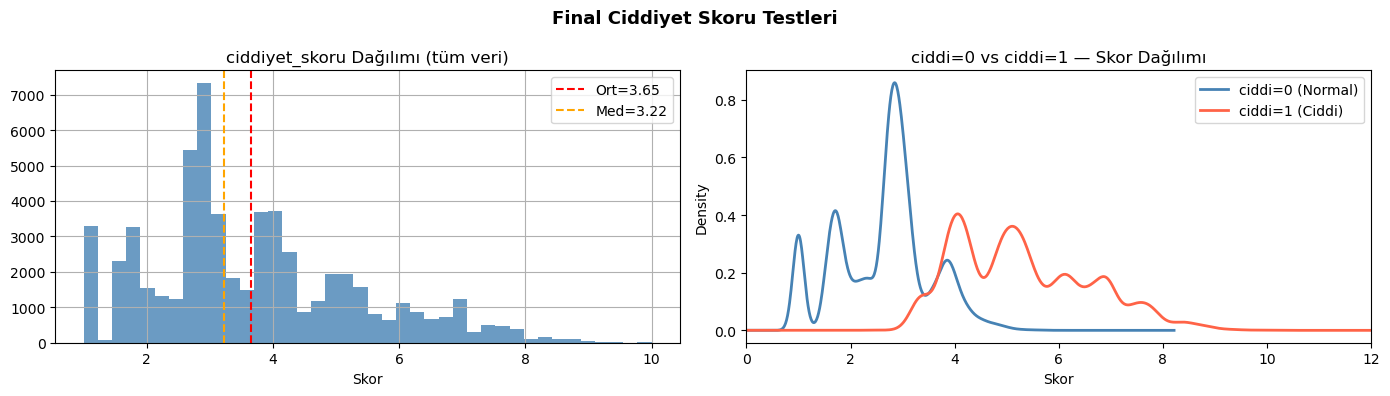

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# PARAMETRELER — buradan değiştir, aşağısı otomatik güncellenir
# ============================================================
W_SONUC  = 0.55   # SONUCTIPI ağırlığı
W_ARIZA  = 0.35   # ARIZAUSTKODTANIM ağırlığı
W_SURE   = 0.10   # TOPLAM_SURE_DK ağırlığı
AZ_KAYIT_ESIK = 10  # Bu sayının altındaki kategoriler global puan alır

sonuc_puan_map = {
    'Telefonla - Servis':  1,
    'Kayıtçı - Garaj':     2,
    'Yol Ustası - Servis': 3,
    'Telefonla - Garaj':   4,
    'Yol Ustası - Garaj':  5,
    'Oto Değişimi':        7,
    'Çekilerek - Garaj':   10,
}

# ============================================================
# PUAN HESAPLAMA FONKSİYONLARI
# ============================================================
sure_p99 = df['TOPLAM_SURE_DK'].quantile(0.99)
sure_medyan = df['TOPLAM_SURE_DK'].median()
global_puan = round(df['ciddi_ariza'].mean() * 10, 2)

# ariza_puan lookup tablosu
ariza_ozet = df.groupby('ARIZAUSTKODTANIM')['ciddi_ariza'].agg(['mean','count']).reset_index()
ariza_ozet.columns = ['ARIZAUSTKODTANIM','ciddi_oran','kayit']
ozel_cats = ['Destek','Sınıflandırılmadı']
az_cats = ariza_ozet[ariza_ozet['kayit'] < AZ_KAYIT_ESIK]['ARIZAUSTKODTANIM'].tolist()
global_cats = ozel_cats + az_cats
ariza_ozet['ariza_puan'] = ariza_ozet.apply(
    lambda r: global_puan if r['ARIZAUSTKODTANIM'] in global_cats
              else round(r['ciddi_oran'] * 10, 2), axis=1
)
ariza_puan_dict = dict(zip(ariza_ozet['ARIZAUSTKODTANIM'], ariza_ozet['ariza_puan']))

# Tüm veri üzerinde skor hesapla
df2 = df.copy()
df2['s_puan']    = df2['SONUCTIPI'].map(sonuc_puan_map)
df2['a_puan']    = df2['ARIZAUSTKODTANIM'].map(ariza_puan_dict).fillna(global_puan)
sure_filled      = df2['TOPLAM_SURE_DK'].fillna(sure_medyan).clip(upper=sure_p99)
df2['sure_puan'] = 1 + (sure_filled / sure_p99) * 9
df2['imdat']     = (df2['IMDAT_TIP'] == 'IETT').astype(int)
df2['ciddiyet_ham'] = (df2['s_puan']*W_SONUC + df2['a_puan']*W_ARIZA +
                       df2['sure_puan']*W_SURE + df2['imdat'])
df2['ciddiyet_skoru'] = df2['ciddiyet_ham'].clip(1, 10).round(2)

print(f'Parametreler: w_sonuc={W_SONUC} | w_ariza={W_ARIZA} | w_sure={W_SURE}')
print(f'sure_p99={sure_p99:.0f} dk | sure_medyan={sure_medyan:.0f} dk | global_puan={global_puan}')
print(f'Az kayıt eşiği: <{AZ_KAYIT_ESIK} → global puan kategoriler: {global_cats}')

# ============================================================
# TEST 1 — Final ağırlıklarla sanity check (2 örnek/SONUCTIPI)
# ============================================================
print('\n' + '='*70)
print('TEST 1: Final ağırlıklarla örnek skorlar')
print('='*70)
ornekler = df2.groupby('SONUCTIPI').apply(lambda g: g.sample(min(2,len(g)), random_state=42)).reset_index(drop=True)
cols = ['SONUCTIPI','ARIZAUSTKODTANIM','TOPLAM_SURE_DK','IMDAT_TIP','s_puan','a_puan','sure_puan','imdat','ciddiyet_skoru']
print(ornekler[cols].to_string(index=False))

# ============================================================
# TEST 2 — ciddi_ariza=0 vs ciddi_ariza=1 skor farkı
# ============================================================
print('\n' + '='*70)
print('TEST 2: ciddi_ariza gruplara göre ciddiyet_skoru')
print('='*70)
gruplar = df2.groupby('ciddi_ariza')['ciddiyet_skoru'].agg(['mean','median','min','max','std']).round(2)
print(gruplar.to_string())
fark = df2[df2['ciddi_ariza']==1]['ciddiyet_skoru'].mean() - df2[df2['ciddi_ariza']==0]['ciddiyet_skoru'].mean()
print(f'\nciddi=1 ile ciddi=0 arasındaki ortalama fark: {fark:.2f} puan')

# ============================================================
# TEST 3 — SONUCTIPI bazında ortalama/min/max skor
# ============================================================
print('\n' + '='*70)
print('TEST 3: SONUCTIPI bazında ortalama skor (beklenen sıralama: 1→10)')
print('='*70)
st_ozet = df2.groupby('SONUCTIPI')['ciddiyet_skoru'].agg(['mean','median','min','max']).round(2)
st_ozet['beklenen_puan'] = st_ozet.index.map(sonuc_puan_map)
st_ozet = st_ozet.sort_values('mean')
print(st_ozet.to_string())
print('\n→ Ortalama skor beklenen puana göre sıralı çıkıyor mu?',
      'EVET ✓' if st_ozet['mean'].is_monotonic_increasing else 'HAYIR ✗ — sıralama bozuk!')

# ============================================================
# TEST 4 — İmdat boost sonrası 10'u aşan kayıt
# ============================================================
print('\n' + '='*70)
print('TEST 4: İmdat boost sonrası 10\'u aşıp clip\'lenen kayıtlar')
print('='*70)
asanlar = df2[df2['ciddiyet_ham'] > 10]
print(f'10\'u aşan kayıt: {len(asanlar):,} (%{len(asanlar)/len(df2)*100:.1f})')
if len(asanlar) > 0:
    print('SONUCTIPI dağılımı:')
    print(asanlar['SONUCTIPI'].value_counts().to_string())

# ============================================================
# TEST 5 — Az kayıtlı yüksek oranlı kategoriler (14-30 arası)
# ============================================================
print('\n' + '='*70)
print(f'TEST 5: Eşiğin üzerinde ama az kayıtlı kategoriler (10-30 kayıt)')
print('='*70)
sinir = ariza_ozet[(ariza_ozet['kayit'] >= AZ_KAYIT_ESIK) & (ariza_ozet['kayit'] < 30)]
sinir = sinir.sort_values('kayit')
print(sinir[['ARIZAUSTKODTANIM','kayit','ciddi_oran','ariza_puan']].to_string(index=False))
print('\n→ Bunların oranları makul mu, yoksa eşiği 30\'a çıkarmalı mıyız?')

# ============================================================
# TEST 6 — Final skor dağılımı
# ============================================================
print('\n' + '='*70)
print('TEST 6: Final ciddiyet_skoru dağılımı')
print('='*70)
print(df2['ciddiyet_skoru'].describe().round(2).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df2['ciddiyet_skoru'].hist(bins=40, ax=axes[0], color='steelblue', alpha=0.8)
axes[0].axvline(df2['ciddiyet_skoru'].mean(), color='red', linestyle='--',
                label=f'Ort={df2["ciddiyet_skoru"].mean():.2f}')
axes[0].axvline(df2['ciddiyet_skoru'].median(), color='orange', linestyle='--',
                label=f'Med={df2["ciddiyet_skoru"].median():.2f}')
axes[0].set_title('ciddiyet_skoru Dağılımı (tüm veri)')
axes[0].set_xlabel('Skor')
axes[0].legend()

# ciddi=0 vs ciddi=1 karşılaştırması
for val, renk, etiket in [(0,'steelblue','ciddi=0 (Normal)'), (1,'tomato','ciddi=1 (Ciddi)')]:
    df2[df2['ciddi_ariza']==val]['ciddiyet_skoru'].plot.kde(ax=axes[1], color=renk, label=etiket, linewidth=2)
axes[1].set_title('ciddi=0 vs ciddi=1 — Skor Dağılımı')
axes[1].set_xlabel('Skor')
axes[1].legend()
axes[1].set_xlim(0, 12)

plt.suptitle('Final Ciddiyet Skoru Testleri', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. ARIZAKODU Seviyesinde Detay — Şüpheli Kategoriler

In [7]:
# Tüm ARIZAUSTKODTANIM kategorileri için ARIZAKODU dağılımına bak
# Özellikle "Destek" ve global puan alanlar şüpheli

# 1. Destek kategorisi — içinde ne var?
print('=== DESTEK KATEGORİSİ — ARIZAKODU DAGILIMI ===')
destek = df[df['ARIZAUSTKODTANIM'] == 'Destek']
print(f'Toplam kayıt: {len(destek):,}')
print(destek['ARIZAKODU'].value_counts().to_string())

print('\n=== DESTEK × SONUCTIPI ===')
print(destek['SONUCTIPI'].value_counts().to_string())

# 2. Destek içindeki her ARIZAKODU için ciddi_ariza oranı
print('\n=== DESTEK — ARIZAKODU BAZINDA CİDDİ ORAN ===')
destek_det = destek.groupby('ARIZAKODU').agg(
    kayit=('ciddi_ariza','count'),
    ciddi_pct=('ciddi_ariza','mean'),
    sonuctipleri=('SONUCTIPI', lambda x: ' | '.join(x.unique()))
).reset_index()
destek_det['ciddi_pct'] = (destek_det['ciddi_pct']*100).round(1)
print(destek_det.sort_values('kayit', ascending=False).to_string(index=False))

# 3. Sınıflandırılmadı içinde ne var?
print('\n=== SINIFLANDIRILMADı — ARIZAKODU DAGILIMI ===')
sinif = df[df['ARIZAUSTKODTANIM'] == 'Sınıflandırılmadı']
print(f'Toplam kayıt: {len(sinif):,}')
print(sinif['ARIZAKODU'].value_counts().head(10).to_string())
print(sinif['SONUCTIPI'].value_counts().to_string())

# 4. Tüm kategoriler için en yaygın 3 ARIZAKODU — genel tablo
print('\n=== TÜM ARIZAUSTKODTANIM — EN SIK 3 ARIZAKODU ===')
for ust, grp in df.groupby('ARIZAUSTKODTANIM'):
    top3 = grp['ARIZAKODU'].value_counts().head(3)
    top3_str = ' | '.join([f'{k}({v})' for k,v in top3.items()])
    n = len(grp)
    ciddi = grp['ciddi_ariza'].mean()*100
    print(f'{ust:<40} n={n:>5} ciddi=%{ciddi:>5.1f} → {top3_str[:80]}')

=== DESTEK KATEGORİSİ — ARIZAKODU DAGILIMI ===
Toplam kayıt: 2,087
ARIZAKODU
Zamanında Müdahale Edilmeme      1163
Yoldan çekici hizmeti             686
Garajlar arası çekici hizmeti     234
Garaj içi Çekici Hizmeti            2
Yoldan Çekici Hizmeti               2

=== DESTEK × SONUCTIPI ===
SONUCTIPI
Çekilerek - Garaj     2086
Yol Ustası - Garaj       1

=== DESTEK — ARIZAKODU BAZINDA CİDDİ ORAN ===
                    ARIZAKODU  kayit  ciddi_pct                           sonuctipleri
  Zamanında Müdahale Edilmeme   1163      100.0                      Çekilerek - Garaj
        Yoldan çekici hizmeti    686      100.0 Çekilerek - Garaj | Yol Ustası - Garaj
Garajlar arası çekici hizmeti    234      100.0                      Çekilerek - Garaj
     Garaj içi Çekici Hizmeti      2      100.0                      Çekilerek - Garaj
        Yoldan Çekici Hizmeti      2      100.0                      Çekilerek - Garaj

=== SINIFLANDIRILMADı — ARIZAKODU DAGILIMI ===
Toplam kayıt: 2
ARIZAKOD

## 10. Temizlik — Anlamsız Kayıtları Çıkar

In [8]:
# Çıkarılacak ARIZAKODU'lar:
# - "Yanlış Kayıt Oluşturma" → veri hatası
# - "GENEL TEMİZLİK" içindeki kayıtlar → arıza değil, periyodik temizlik
# "Garajlar arası çekici hizmeti" → şimdilik kalıyor (Yol B ile ele alınacak)

cikarilacak_kodlar = [
    'Yanlış Kayıt Oluşturma',
    'GENEL PERİYODİK İÇ TEMİZLİK YAPILACAK',
    'İÇ KABİN TEMİZLİĞİ',
]

print('=== TEMİZLİK ÖNCESİ ===')
print(f'Toplam kayıt: {len(df):,}')

# Silinecekleri göster
silinen = df[df['ARIZAKODU'].isin(cikarilacak_kodlar)]
print(f'\nSilinecek kayıt: {len(silinen)}')
print(silinen[['ARIZAKODU','ARIZAUSTKODTANIM','SONUCTIPI','ciddi_ariza']].value_counts().to_string())

# Temizle
df_temiz = df[~df['ARIZAKODU'].isin(cikarilacak_kodlar)].reset_index(drop=True)

print(f'\n=== TEMİZLİK SONRASI ===')
print(f'Kalan kayıt: {len(df_temiz):,} (silinen: {len(df) - len(df_temiz)})')
print(f'ciddi_ariza: %{df_temiz["ciddi_ariza"].mean()*100:.1f}')

# Kaydet
out = 'panel_data/temiz_veri/ariza_model.csv'
df_temiz.to_csv(out, index=False, encoding='utf-8-sig')
print(f'\nariza_model.csv güncellendi → {len(df_temiz):,} satır')

# df'i de güncelle (sonraki hücreler için)
df = df_temiz
print('✓ df güncellendi')

=== TEMİZLİK ÖNCESİ ===
Toplam kayıt: 58,559

Silinecek kayıt: 0
Series([], )

=== TEMİZLİK SONRASI ===
Kalan kayıt: 58,559 (silinen: 0)
ciddi_ariza: %38.0

ariza_model.csv güncellendi → 58,559 satır
✓ df güncellendi


## 11. Yol B — "Garajlar Arası Çekici" için Önceki Arıza Kaydını Bul

In [9]:
import pandas as pd

df['OLAYTARIHI'] = pd.to_datetime(df['OLAYTARIHI'], format='mixed')

# Garajlar arası çekici kayıtları
garaj_transfer = df[df['ARIZAKODU'] == 'Garajlar arası çekici hizmeti'].copy()

# Geriye dönük arama için kullanılacak havuz:
# - Aynı aracın önceki kayıtları
# - "Garajlar arası çekici" olmayan kayıtlar (gerçek arıza tipleri)
havuz = df[df['ARIZAKODU'] != 'Garajlar arası çekici hizmeti'].copy()

print(f'Eşleştirilecek transfer kayıt: {len(garaj_transfer)}')
print(f'Arama havuzu: {len(havuz):,} kayıt')

# Zaman penceresi: transfer tarihinden kaç gün önceye bakacağız?
PENCERE_GUN = 30

eslesmeler = []
eslesmedi = []

for _, row in garaj_transfer.iterrows():
    kapino = row['KAPINO']
    tarih = row['OLAYTARIHI']

    # Aynı araca ait, bu tarihten önceki, son PENCERE_GUN içindeki kayıtlar
    aday = havuz[
        (havuz['KAPINO'] == kapino) &
        (havuz['OLAYTARIHI'] < tarih) &
        (havuz['OLAYTARIHI'] >= tarih - pd.Timedelta(days=PENCERE_GUN))
    ].sort_values('OLAYTARIHI', ascending=False)

    if len(aday) > 0:
        # En yakın önceki kaydı al
        en_yakin = aday.iloc[0]
        eslesmeler.append({
            'KAPINO': kapino,
            'transfer_tarihi': tarih,
            'onceki_tarih': en_yakin['OLAYTARIHI'],
            'gun_fark': (tarih - en_yakin['OLAYTARIHI']).days,
            'eski_ust': row['ARIZAUSTKODTANIM'],
            'yeni_ust': en_yakin['ARIZAUSTKODTANIM'],
            'yeni_arizakodu': en_yakin['ARIZAKODU'],
            'onceki_sonuctipi': en_yakin['SONUCTIPI'],
        })
    else:
        eslesmedi.append(kapino)

eslesme_df = pd.DataFrame(eslesmeler)
print(f'\n=== EŞLEŞME SONUCU ({PENCERE_GUN} gün pencere) ===')
print(f'Eşleşen:    {len(eslesme_df):,} kayıt (%{len(eslesme_df)/len(garaj_transfer)*100:.1f})')
print(f'Eşleşmeyen: {len(eslesmedi):,} kayıt (global puan alacak)')

if len(eslesme_df) > 0:
    print(f'\nGün farkı istatistikleri:')
    print(eslesme_df['gun_fark'].describe().round(1).to_string())

    print(f'\nEşleşen kayıtlarda bulunan arıza üst kategorileri:')
    print(eslesme_df['yeni_ust'].value_counts().head(15).to_string())

    print(f'\nEşleşen kayıtlarda önceki SONUCTIPI:')
    print(eslesme_df['onceki_sonuctipi'].value_counts().to_string())

    print(f'\nÖrnek 10 eşleşme:')
    print(eslesme_df[['KAPINO','gun_fark','eski_ust','yeni_ust','onceki_sonuctipi']].head(10).to_string(index=False))

Eşleştirilecek transfer kayıt: 444
Arama havuzu: 58,115 kayıt

=== EŞLEŞME SONUCU (30 gün pencere) ===
Eşleşen:    401 kayıt (%90.3)
Eşleşmeyen: 43 kayıt (global puan alacak)

Gün farkı istatistikleri:
count    401.0
mean       4.5
std        6.4
min        0.0
25%        0.0
50%        2.0
75%        6.0
max       28.0

Eşleşen kayıtlarda bulunan arıza üst kategorileri:
yeni_ust
ELEKTRİK SİSTEMİ ARIZALARI            51
SOĞUTMA SİSTEMİ ARIZASI               41
MOTOR ARIZALARI                       40
KAPI ARIZALARI                        36
KAROSER ARIZALARI                     25
KLİMA SİSTEMİ ARIZALARI               24
OTOMATİK ŞANZIMAN ARIZALARI           23
FREN ŞİKAYETLERİ                      23
Destek                                22
İLAVE DİREKSİYON SİSTEMİ ARIZALARI    15
SÜSPANSİYON SİSTEMİ ARIZALARI         12
ISITMA SİSTEMİ                        12
BASINÇLI YAĞ HATTI ARIZASI            11
BASINÇLI HAVA DONANIMI ARIZALARI       9
ŞAFT ARIZALARI                         7

E

In [10]:
# Yol B sonucu: guveniLir tanımla (14 gun, Destek ve Telefon-Servis hariç)
MAX_GUN = 14

guveniLir = eslesme_df[
    (eslesme_df['gun_fark'] <= MAX_GUN) &
    (eslesme_df['yeni_ust'] != 'Destek') &
    (eslesme_df['onceki_sonuctipi'] != 'Telefonla - Servis')
].copy()

guvensiz = eslesme_df[~eslesme_df.index.isin(guveniLir.index)]

print(f'Guvenilir esleme: {len(guveniLir):,} (%{len(guveniLir)/len(garaj_transfer)*100:.1f})')
print(f'Guvensiz/global puan: {len(guvensiz)+len(eslesmedi):,}')


Guvenilir esleme: 338 (%76.1)
Guvensiz/global puan: 106


## 13. Pencere Validasyonu — 5 gün mu 14 gün mü?

In [11]:
"""
Hipotez: Önceki arızanın SONUCTIPI garaja gitme içeriyorsa (güçlü bağlantı),
o eşleşme gerçektir. Servis ile kapandıysa (zayıf bağlantı), tesadüfi olabilir.

Güçlü bağlantı: Yol Ustası-Garaj, Çekilerek-Garaj, Oto Değişimi, Telefonla-Garaj
Zayıf bağlantı: Yol Ustası-Servis, Kayıtçı-Garaj, Telefonla-Servis
"""

guclu = {'Yol Ustası - Garaj', 'Çekilerek - Garaj', 'Oto Değişimi', 'Telefonla - Garaj'}
zayif = {'Yol Ustası - Servis', 'Kayıtçı - Garaj', 'Telefonla - Servis'}

def baglanti_kalite(df_eslesme):
    guclu_n = df_eslesme['onceki_sonuctipi'].isin(guclu).sum()
    zayif_n = df_eslesme['onceki_sonuctipi'].isin(zayif).sum()
    toplam = len(df_eslesme)
    return guclu_n, zayif_n, toplam

# Test 1: Tüm pencereler için güçlü/zayıf bağlantı oranı
print('=== TEST 1: GÜÇLÜ vs ZAYIF BAĞLANTI ORANI ===')
print(f'{"Pencere":<12} {"Toplam":>8} {"Güçlü":>8} {"Güçlü%":>8} {"Zayıf":>8} {"Zayıf%":>8}')
for pencere in [3, 5, 7, 10, 14]:
    g = eslesme_df[
        (eslesme_df['gun_fark'] <= pencere) &
        (eslesme_df['yeni_ust'] != 'Destek') &
        (eslesme_df['onceki_sonuctipi'] != 'Telefonla - Servis')
    ]
    guclu_n, zayif_n, top = baglanti_kalite(g)
    print(f'{pencere} gün{"":<7} {top:>8} {guclu_n:>8} {guclu_n/top*100:>7.1f}% {zayif_n:>8} {zayif_n/top*100:>7.1f}%')

# Test 2: Sadece 5-14 gün arasındaki kayıtlar — bunlar güvenilir mi?
print('\n=== TEST 2: 6-14 GÜN ARASINDAKI (tartışmalı) KAYITLAR ===')
tartismali = eslesme_df[
    (eslesme_df['gun_fark'] >= 6) &
    (eslesme_df['gun_fark'] <= 14) &
    (eslesme_df['yeni_ust'] != 'Destek') &
    (eslesme_df['onceki_sonuctipi'] != 'Telefonla - Servis')
]
guclu_n, zayif_n, top = baglanti_kalite(tartismali)
print(f'Toplam tartışmalı kayıt: {top}')
print(f'Güçlü bağlantı: {guclu_n} (%{guclu_n/top*100:.1f})')
print(f'Zayıf bağlantı: {zayif_n} (%{zayif_n/top*100:.1f})')
print('\nSayısal dağılım:')
print(tartismali['onceki_sonuctipi'].value_counts().to_string())

# Test 3: Zayıf bağlantılı kayıtlar nereye düşüyor — arıza kategorisi makul mu?
print('\n=== TEST 3: ZAYIF BAĞLANTILI KAYITLAR — ARIZA KATEGORİSİ ===')
print('(Bunlar garaja gitmeden önce "çözüldü" denilen ama transfer edilen kayıtlar)')
for pencere, isim in [(5,'5 gün'), (14,'14 gün')]:
    g = eslesme_df[
        (eslesme_df['gun_fark'] <= pencere) &
        (eslesme_df['yeni_ust'] != 'Destek') &
        (eslesme_df['onceki_sonuctipi'] != 'Telefonla - Servis') &
        (eslesme_df['onceki_sonuctipi'].isin(zayif))
    ]
    print(f'\n{isim} — zayıf bağlantılı {len(g)} kayıt:')
    print(g['yeni_ust'].value_counts().head(8).to_string())

# Test 4: Ortalama gün farkı pencere içinde nasıl dağılıyor?
print('\n=== TEST 4: GÜN FARKI DAĞILIMI (güvenilir eşleşmeler) ===')
guclu_eslesme = eslesme_df[
    (eslesme_df['gun_fark'] <= 14) &
    (eslesme_df['yeni_ust'] != 'Destek') &
    (eslesme_df['onceki_sonuctipi'] != 'Telefonla - Servis')
]
print(guclu_eslesme['gun_fark'].value_counts().sort_index().to_string())
print(f'\nKümülatif — 5 güne kadar: %{(guclu_eslesme["gun_fark"] <= 5).mean()*100:.1f}')
print(f'Kümülatif — 7 güne kadar: %{(guclu_eslesme["gun_fark"] <= 7).mean()*100:.1f}')
print(f'Kümülatif — 10 güne kadar: %{(guclu_eslesme["gun_fark"] <= 10).mean()*100:.1f}')

=== TEST 1: GÜÇLÜ vs ZAYIF BAĞLANTI ORANI ===
Pencere        Toplam    Güçlü   Güçlü%    Zayıf   Zayıf%
3 gün             229      134    58.5%       95    41.5%
5 gün             264      145    54.9%      119    45.1%
7 gün             280      153    54.6%      127    45.4%
10 gün             308      166    53.9%      142    46.1%
14 gün             338      177    52.4%      161    47.6%

=== TEST 2: 6-14 GÜN ARASINDAKI (tartışmalı) KAYITLAR ===
Toplam tartışmalı kayıt: 74
Güçlü bağlantı: 32 (%43.2)
Zayıf bağlantı: 42 (%56.8)

Sayısal dağılım:
onceki_sonuctipi
Yol Ustası - Garaj     29
Yol Ustası - Servis    29
Kayıtçı - Garaj        13
Telefonla - Garaj       1
Oto Değişimi            1
Çekilerek - Garaj       1

=== TEST 3: ZAYIF BAĞLANTILI KAYITLAR — ARIZA KATEGORİSİ ===
(Bunlar garaja gitmeden önce "çözüldü" denilen ama transfer edilen kayıtlar)

5 gün — zayıf bağlantılı 119 kayıt:
yeni_ust
KAPI ARIZALARI                18
ELEKTRİK SİSTEMİ ARIZALARI    17
SOĞUTMA SİSTEMİ ARIZA

## 14. Sefer Verisiyle Doğrulama — Araç Garajda Mı Bekledi?

In [12]:
import pandas as pd

# Sefer verisini yükle
sefer = pd.read_csv('panel_data/temiz_veri/arac_gunluk_hatlar.csv')
sefer['TARIH'] = pd.to_datetime(sefer['TARIH'])
print(f'Sefer veri: {len(sefer):,} satır')
print(f'Kolonlar: {list(sefer.columns)}')
print(f'Örnek:')
print(sefer.head(3).to_string())

# Her pencere için: araç arıza tarihi ile transfer tarihi arasında sefere çıktı mı?
def sefer_kontrolu(eslesme_df_filtre, pencere_adi):
    sonuclar = []
    for _, row in eslesme_df_filtre.iterrows():
        kapino = row['KAPINO']
        baslangic = row['onceki_tarih'].normalize()  # arıza tarihi
        bitis = row['transfer_tarihi'].normalize()   # transfer tarihi

        if baslangic >= bitis:
            # Aynı gün — kontrol yapılamaz
            sonuclar.append('ayni_gun')
            continue

        # Arıza ile transfer arasındaki günler
        aradaki_gunler = sefer[
            (sefer['KAPINO'] == kapino) &
            (sefer['TARIH'] > baslangic) &
            (sefer['TARIH'] < bitis)
        ]

        toplam_sefer = aradaki_gunler['SEFER_SAYISI'].sum() if len(aradaki_gunler) > 0 else 0

        if toplam_sefer == 0:
            sonuclar.append('garajda_bekledi')   # güçlü bağlantı
        else:
            sonuclar.append('sefere_cikti')       # zayıf bağlantı

    return pd.Series(sonuclar).value_counts()

# 5 günlük pencere için test
eslesme_5 = eslesme_df[
    (eslesme_df['gun_fark'] <= 5) &
    (eslesme_df['yeni_ust'] != 'Destek') &
    (eslesme_df['onceki_sonuctipi'] != 'Telefonla - Servis')
].copy()

# 14 günlük pencere için test
eslesme_14 = guveniLir.copy()

# Sadece gun_fark > 0 olanlar için (aynı gün olanlar zaten güçlü)
eslesme_5_farki = eslesme_5[eslesme_5['gun_fark'] > 0]
eslesme_14_farki = eslesme_14[eslesme_14['gun_fark'] > 0]

print(f'\n=== SEFER KONTROLÜ — 5 GÜN ({len(eslesme_5_farki)} kayıt, gun_fark>0) ===')
print(sefer_kontrolu(eslesme_5_farki, '5 gün').to_string())

print(f'\n=== SEFER KONTROLÜ — 14 GÜN ({len(eslesme_14_farki)} kayıt, gun_fark>0) ===')
print(sefer_kontrolu(eslesme_14_farki, '14 gün').to_string())

# Sadece 6-14 gün arası (tartışmalı)
tartismali_farki = eslesme_14[eslesme_14['gun_fark'] >= 6]
print(f'\n=== SEFER KONTROLÜ — SADECE 6-14 GÜN ARASI ({len(tartismali_farki)} kayıt) ===')
print(sefer_kontrolu(tartismali_farki, '6-14 gün').to_string())


Sefer veri: 1,320,647 satır
Kolonlar: ['KAPINO', 'TARIH', 'HATKODU', 'SEFER_SAYISI']
Örnek:
  KAPINO      TARIH HATKODU  SEFER_SAYISI
0  A1203 2025-01-01     146             5
1  A1203 2025-01-02     146             4
2  A1203 2025-01-03     146             4

=== SEFER KONTROLÜ — 5 GÜN (123 kayıt, gun_fark>0) ===
sefere_cikti       101
garajda_bekledi     22

=== SEFER KONTROLÜ — 14 GÜN (197 kayıt, gun_fark>0) ===
sefere_cikti       175
garajda_bekledi     22

=== SEFER KONTROLÜ — SADECE 6-14 GÜN ARASI (74 kayıt) ===
sefere_cikti    74


## 15. Seçenek A vs B — Önizleme (kaydetmez)

In [13]:
import pandas as pd

sefer = pd.read_csv('panel_data/temiz_veri/arac_gunluk_hatlar.csv')
sefer['TARIH'] = pd.to_datetime(sefer['TARIH'])

def sefer_durumu(row):
    if row['gun_fark'] == 0:
        return 'ayni_gun'
    baslangic = pd.Timestamp(row['onceki_tarih']).normalize()
    bitis = pd.Timestamp(row['transfer_tarihi']).normalize()
    aradaki = sefer[
        (sefer['KAPINO'] == row['KAPINO']) &
        (sefer['TARIH'] > baslangic) &
        (sefer['TARIH'] < bitis)
    ]
    return 'garajda_bekledi' if aradaki['SEFER_SAYISI'].sum() == 0 else 'sefere_cikti'

eslesme_5 = eslesme_df[
    (eslesme_df['gun_fark'] <= 5) &
    (eslesme_df['yeni_ust'] != 'Destek') &
    (eslesme_df['onceki_sonuctipi'] != 'Telefonla - Servis')
].copy()

print('Sefer kontrolu calistirilıyor...')
eslesme_5['sefer_durumu'] = eslesme_5.apply(sefer_durumu, axis=1)
print(eslesme_5['sefer_durumu'].value_counts().to_string())

secA = eslesme_5[eslesme_5['gun_fark'] == 0].copy()
secB = eslesme_5[
    (eslesme_5['gun_fark'] == 0) |
    (eslesme_5['sefer_durumu'] == 'garajda_bekledi')
].copy()

print('\n=== KARSILASTIRMA ===')
print(f'{"":35} {"Secenek A":>12} {"Secenek B":>12}')
print(f'{"Guvenilir esleme":35} {len(secA):>12,} {len(secB):>12,}')
pctA = len(secA) / len(garaj_transfer) * 100
pctB = len(secB) / len(garaj_transfer) * 100
print(f'{"Esleme orani":35} {pctA:>11.1f}% {pctB:>11.1f}%')
print(f'{"Global puan alacak":35} {len(garaj_transfer)-len(secA):>12,} {len(garaj_transfer)-len(secB):>12,}')

TRANSFER_KOD = 'Garajlar arası çekici hizmeti'

def uygula(secim, isim):
    # OLAYTARIHI'ni datetime'a cevir
    df_local = df.copy()
    df_local['OLAYTARIHI'] = pd.to_datetime(df_local['OLAYTARIHI'], format='mixed')

    eslesme_map_local = {}
    for _, row in secim.iterrows():
        eslesme_map_local[(row['KAPINO'], row['transfer_tarihi'])] = row['yeni_ust']

    transfer_mask = df_local['ARIZAKODU'] == TRANSFER_KOD
    print(f'\n--- {isim} ---')
    print(f'Transfer maskesi eslesen kayit: {transfer_mask.sum()}')

    guncellenen = 0
    for idx, row in df_local[transfer_mask].iterrows():
        anahtar = (row['KAPINO'], row['OLAYTARIHI'])
        if anahtar in eslesme_map_local:
            df_local.at[idx, 'ARIZAUSTKODTANIM'] = eslesme_map_local[anahtar]
            guncellenen += 1

    print(f'Guncellenen: {guncellenen} | Global puan kalacak: {transfer_mask.sum()-guncellenen}')
    print('ARIZAUSTKODTANIM dagilimi (Destek kayitlarinda):')
    print(df_local[transfer_mask]['ARIZAUSTKODTANIM'].value_counts().head(12).to_string())
    return df_local

df_secA = uygula(secA, 'SECENEK A (sadece gun_fark=0)')
df_secB = uygula(secB, 'SECENEK B (gun_fark=0 + garajda_bekledi)')
print('\n--- Henuz kaydedilmedi ---')


Sefer kontrolu calistirilıyor...
sefer_durumu
ayni_gun           141
sefere_cikti       101
garajda_bekledi     22

=== KARSILASTIRMA ===
                                       Secenek A    Secenek B
Guvenilir esleme                             141          163
Esleme orani                               31.8%        36.7%
Global puan alacak                           303          281

--- SECENEK A (sadece gun_fark=0) ---
Transfer maskesi eslesen kayit: 444
Guncellenen: 141 | Global puan kalacak: 303
ARIZAUSTKODTANIM dagilimi (Destek kayitlarinda):
ARIZAUSTKODTANIM
Destek                                234
ELEKTRİK SİSTEMİ ARIZALARI             32
SOĞUTMA SİSTEMİ ARIZASI                25
MOTOR ARIZALARI                        20
OTOMATİK ŞANZIMAN ARIZALARI            17
KAPI ARIZALARI                         15
FREN ŞİKAYETLERİ                       14
KAROSER ARIZALARI                      11
KLİMA SİSTEMİ ARIZALARI                10
İLAVE DİREKSİYON SİSTEMİ ARIZALARI      9
ŞAFT ARIZ

## 16. Seçenek B'yi Uygula ve Kaydet

In [14]:
# Seçenek B onaylandı — df'i güncelle ve kaydet
df = df_secB.copy()

# Doğrulama
transfer_mask = df['ARIZAKODU'] == 'Garajlar arası çekici hizmeti'
print(f'Toplam transfer kaydı: {transfer_mask.sum()}')
print(f'Destek olarak kalan: {(df[transfer_mask]["ARIZAUSTKODTANIM"] == "Destek").sum()}')
print(f'Gerçek arıza tipine kavuşan: {(df[transfer_mask]["ARIZAUSTKODTANIM"] != "Destek").sum()}')
print(f'Toplam kayıt: {len(df):,}')
print(f'ciddi_ariza: %{df["ciddi_ariza"].mean()*100:.1f}')

out = 'panel_data/temiz_veri/ariza_model.csv'
df.to_csv(out, index=False, encoding='utf-8-sig')
print(f'\nariza_model.csv kaydedildi — {len(df):,} satır, {len(df.columns)} kolon')


Toplam transfer kaydı: 444
Destek olarak kalan: 234
Gerçek arıza tipine kavuşan: 210
Toplam kayıt: 58,559
ciddi_ariza: %38.0

ariza_model.csv kaydedildi — 58,559 satır, 26 kolon


## 17. 281 Eşleşemeyen Kayıt — Son Sefer Gününden Köken Arıza Bul

In [15]:
import pandas as pd

# Sefer verisi
sefer = pd.read_csv('panel_data/temiz_veri/arac_gunluk_hatlar.csv')
sefer['TARIH'] = pd.to_datetime(sefer['TARIH'])

# Güncel df'teki eşleşemeyen 281 kayıt
df_guncel = pd.read_csv('panel_data/temiz_veri/ariza_model.csv', low_memory=False)
df_guncel['OLAYTARIHI'] = pd.to_datetime(df_guncel['OLAYTARIHI'], format='mixed')

eslesmeyen = df_guncel[
    (df_guncel['ARIZAKODU'] == 'Garajlar arası çekici hizmeti') &
    (df_guncel['ARIZAUSTKODTANIM'] == 'Destek')
].copy()
print(f'Eşleşemeyen kayıt: {len(eslesmeyen)}')

# Arıza havuzu — gerçek arıza kayıtları
havuz = df_guncel[
    (df_guncel['ARIZAKODU'] != 'Garajlar arası çekici hizmeti') &
    (~df_guncel['ARIZAUSTKODTANIM'].isin(['Destek', 'Sınıflandırılmadı']))
].copy()

sonuclar = []
for _, row in eslesmeyen.iterrows():
    kapino = row['KAPINO']
    transfer_tarih = row['OLAYTARIHI'].normalize()

    # 1. ADIM: Son sefer gününü bul (transfer tarihinden önce)
    arac_seferler = sefer[
        (sefer['KAPINO'] == kapino) &
        (sefer['TARIH'] < transfer_tarih) &
        (sefer['SEFER_SAYISI'] > 0)
    ]

    if len(arac_seferler) == 0:
        sonuclar.append({'durum': 'sefer_yok'})
        continue

    son_sefer_gun = arac_seferler['TARIH'].max()
    gun_fark_sefer = (transfer_tarih - son_sefer_gun).days

    # 2. ADIM: Son sefer gününden sonraki 3 gün içinde arıza var mı?
    aday = havuz[
        (havuz['KAPINO'] == kapino) &
        (havuz['OLAYTARIHI'].dt.normalize() >= son_sefer_gun) &
        (havuz['OLAYTARIHI'].dt.normalize() <= son_sefer_gun + pd.Timedelta(days=3))
    ].sort_values('OLAYTARIHI', ascending=False)

    if len(aday) > 0:
        en_yakin = aday.iloc[0]
        sonuclar.append({
            'KAPINO': kapino,
            'transfer_tarih': transfer_tarih,
            'son_sefer_gun': son_sefer_gun,
            'gun_fark_sefer': gun_fark_sefer,
            'bulunan_ust': en_yakin['ARIZAUSTKODTANIM'],
            'bulunan_sonuctipi': en_yakin['SONUCTIPI'],
            'durum': 'eslesti'
        })
    else:
        sonuclar.append({
            'KAPINO': kapino,
            'son_sefer_gun': son_sefer_gun,
            'gun_fark_sefer': gun_fark_sefer,
            'durum': 'ariza_yok'
        })

sonuc_df = pd.DataFrame(sonuclar)
print(f'\n=== SONUÇ ===')
print(sonuc_df['durum'].value_counts().to_string())

eslesen = sonuc_df[sonuc_df['durum'] == 'eslesti']
if len(eslesen) > 0:
    print(f'\nEşleşen {len(eslesen)} kayıt — son sefer gün farkı:')
    print(eslesen['gun_fark_sefer'].describe().round(1).to_string())
    print(f'\nBulunan arıza üst kategorileri:')
    print(eslesen['bulunan_ust'].value_counts().head(12).to_string())
    print(f'\nÖnceki SONUCTIPI:')
    print(eslesen['bulunan_sonuctipi'].value_counts().to_string())
    print(f'\nÖrnek 5 eşleşme:')
    print(eslesen[['KAPINO','son_sefer_gun','gun_fark_sefer','bulunan_ust','bulunan_sonuctipi']].head(5).to_string(index=False))


Eşleşemeyen kayıt: 234

=== SONUÇ ===
durum
ariza_yok    224
sefer_yok      7
eslesti        3

Eşleşen 3 kayıt — son sefer gün farkı:
count    3.0
mean     1.0
std      0.0
min      1.0
25%      1.0
50%      1.0
75%      1.0
max      1.0

Bulunan arıza üst kategorileri:
bulunan_ust
AKBİL ARIZALARI                       1
İLAVE DİREKSİYON SİSTEMİ ARIZALARI    1
ISITMA SİSTEMİ                        1

Önceki SONUCTIPI:
bulunan_sonuctipi
Telefonla - Servis    3

Örnek 5 eşleşme:
KAPINO son_sefer_gun  gun_fark_sefer                        bulunan_ust  bulunan_sonuctipi
 B4902    2025-05-14             1.0                    AKBİL ARIZALARI Telefonla - Servis
 K5755    2025-05-13             1.0 İLAVE DİREKSİYON SİSTEMİ ARIZALARI Telefonla - Servis
 O4561    2025-05-09             1.0                     ISITMA SİSTEMİ Telefonla - Servis


## 18. gun_fark=0 Eşleşmeler — Aynı Timestamp mi, Farklı Saat mi?

In [16]:
import pandas as pd

df_guncel = pd.read_csv('panel_data/temiz_veri/ariza_model.csv', low_memory=False)
df_guncel['OLAYTARIHI'] = pd.to_datetime(df_guncel['OLAYTARIHI'], format='mixed')

# gun_fark=0 olan eşleşmeleri yeniden bul
transfer_kayitlar = df_guncel[
    df_guncel['ARIZAKODU'] == 'Garajlar arası çekici hizmeti'
].copy()

havuz = df_guncel[
    df_guncel['ARIZAKODU'] != 'Garajlar arası çekici hizmeti'
].copy()

ayni_timestamp = []
ayni_gun_farkli_saat = []

for _, row in transfer_kayitlar.iterrows():
    kapino = row['KAPINO']
    tarih = row['OLAYTARIHI']
    gun = tarih.normalize()

    # Aynı araç, aynı gün, farklı kayıt
    ayni_gun = havuz[
        (havuz['KAPINO'] == kapino) &
        (havuz['OLAYTARIHI'].dt.normalize() == gun)
    ]

    if len(ayni_gun) == 0:
        continue

    for _, orig in ayni_gun.iterrows():
        fark_saniye = abs((tarih - orig['OLAYTARIHI']).total_seconds())
        if fark_saniye == 0:
            ayni_timestamp.append({
                'KAPINO': kapino,
                'OLAYTARIHI': tarih,
                'orig_sonuctipi': orig['SONUCTIPI'],
                'orig_ust': orig['ARIZAUSTKODTANIM'],
            })
        else:
            ayni_gun_farkli_saat.append({
                'KAPINO': kapino,
                'transfer_saat': tarih,
                'orig_saat': orig['OLAYTARIHI'],
                'fark_saat': round(fark_saniye/3600, 2),
                'orig_sonuctipi': orig['SONUCTIPI'],
                'orig_ust': orig['ARIZAUSTKODTANIM'],
            })

print(f'=== gun_fark=0 EŞLEŞMELERİN TİP DAĞILIMI ===')
print(f'Birebir aynı timestamp (saniye farkı=0): {len(ayni_timestamp)}')
print(f'Aynı gün farklı saat:                    {len(ayni_gun_farkli_saat)}')

if len(ayni_timestamp) > 0:
    df_ts = pd.DataFrame(ayni_timestamp)
    print(f'\nAynı timestamp — önceki SONUCTIPI:')
    print(df_ts['orig_sonuctipi'].value_counts().to_string())
    print(f'\nÖrnek 5:')
    print(df_ts.head(5).to_string(index=False))

if len(ayni_gun_farkli_saat) > 0:
    df_fs = pd.DataFrame(ayni_gun_farkli_saat)
    print(f'\nFarklı saat — saat farkı dağılımı (saat cinsinden):')
    print(df_fs['fark_saat'].describe().round(2).to_string())
    print(f'\nÖrnek 5:')
    print(df_fs[['KAPINO','transfer_saat','orig_saat','fark_saat','orig_sonuctipi','orig_ust']].head(5).to_string(index=False))


=== gun_fark=0 EŞLEŞMELERİN TİP DAĞILIMI ===
Birebir aynı timestamp (saniye farkı=0): 0
Aynı gün farklı saat:                    130

Farklı saat — saat farkı dağılımı (saat cinsinden):
count    130.00
mean       4.53
std        4.39
min        0.00
25%        1.60
50%        2.90
75%        6.45
max       21.87

Örnek 5:
KAPINO       transfer_saat           orig_saat  fark_saat      orig_sonuctipi                           orig_ust
 A3641 2025-01-03 13:37:31 2025-01-03 08:13:20       5.40 Yol Ustası - Servis            SOĞUTMA SİSTEMİ ARIZASI
 A4811 2025-06-23 21:20:39 2025-06-23 14:03:15       7.29 Yol Ustası - Servis                    MOTOR ARIZALARI
 A4811 2025-06-23 21:20:39 2025-06-23 15:39:56       5.68   Çekilerek - Garaj         BASINÇLI YAĞ HATTI ARIZASI
 A4834 2025-03-17 21:56:40 2025-03-17 18:35:08       3.36   Çekilerek - Garaj         BASINÇLI YAĞ HATTI ARIZASI
 A5225 2025-06-07 19:01:43 2025-06-07 18:26:24       0.59  Yol Ustası - Garaj İLAVE DİREKSİYON SİSTEMİ ARIZALAR

## 19. Son Sefer Köken — Kalite Filtresi + Kaydet

In [17]:
import pandas as pd

zayif_ust = {'AKBİL ARIZALARI', 'KAMERA SİSTEMİ ARIZALARI'}
zayif_sonuc = {'Telefonla - Servis'}

eslesen_temiz = eslesen[
    (~eslesen['bulunan_ust'].isin(zayif_ust)) &
    (~eslesen['bulunan_sonuctipi'].isin(zayif_sonuc))
].copy()

print(f'Ham esleme: {len(eslesen)} | Filtre sonrasi: {len(eslesen_temiz)} | Dusen: {len(eslesen)-len(eslesen_temiz)}')
print('Kalan kategoriler:')
print(eslesen_temiz['bulunan_ust'].value_counts().to_string())

df_guncel = pd.read_csv('panel_data/temiz_veri/ariza_model.csv', low_memory=False)
df_guncel['OLAYTARIHI'] = pd.to_datetime(df_guncel['OLAYTARIHI'], format='mixed')

# Anahtar: KAPINO + OLAYTARIHI (tam datetime, normalize degil)
# eslesen_temiz'deki transfer_tarih normalize edilmis — orijinal timestamp'i bul
eslesmeyen_full = df_guncel[
    (df_guncel['ARIZAKODU'] == 'Garajlar arası çekici hizmeti') &
    (df_guncel['ARIZAUSTKODTANIM'] == 'Destek')
].copy()

# Normalize edilmis tarihi KAPINO ile eslestir
eslesme_map = {}
for _, row in eslesen_temiz.iterrows():
    kapino = row['KAPINO']
    gun = pd.Timestamp(row['transfer_tarih']).normalize()
    eslesme_map[(kapino, gun)] = row['bulunan_ust']

guncellenen = 0
for idx, row in eslesmeyen_full.iterrows():
    anahtar = (row['KAPINO'], row['OLAYTARIHI'].normalize())
    if anahtar in eslesme_map:
        df_guncel.at[idx, 'ARIZAUSTKODTANIM'] = eslesme_map[anahtar]
        guncellenen += 1

print(f'\n=== GUNCELLEME ===')
print(f'Guncellenen: {guncellenen}')

garaj_tr = df_guncel[df_guncel['ARIZAKODU'] == 'Garajlar arası çekici hizmeti']
hala_destek = (garaj_tr['ARIZAUSTKODTANIM'] == 'Destek').sum()
gercek = (garaj_tr['ARIZAUSTKODTANIM'] != 'Destek').sum()
print(f'Gercek ariza tipine kavusan: {gercek}')
print(f'Hala Destek (global puan): {hala_destek}')

out = 'panel_data/temiz_veri/ariza_model.csv'
df_guncel.to_csv(out, index=False, encoding='utf-8-sig')
print(f'\nariza_model.csv kaydedildi — {len(df_guncel):,} satir')


Ham esleme: 3 | Filtre sonrasi: 0 | Dusen: 3
Kalan kategoriler:
Series([], )

=== GUNCELLEME ===
Guncellenen: 0
Gercek ariza tipine kavusan: 210
Hala Destek (global puan): 234

ariza_model.csv kaydedildi — 58,559 satir


## 20. Kapsamlı Validasyon — Metrik ve Kategori Kontrolü

TEST A: ARIZAKODU İÇİ VARYANS ANALİZİ
(Yüksek std = o üst kategoride alt kodlar çok farklı ciddiyet gösteriyor)
                  ARIZAUSTKODTANIM  n_kayit  n_alt_kod  ust_puan  ust_ciddi_oran  alt_ciddi_std
       BASINÇLI HAVA HATTI ARIZASI    478.0        7.0      3.43           0.343          0.399
                  LASTİK ARIZALARI    507.0       25.0      2.56           0.256          0.378
                   MOTOR ARIZALARI   5637.0       44.0      5.48           0.548          0.369
             YANGIN İKAZ ARIZALARI    200.0        4.0      6.90           0.690          0.368
  BASINÇLI HAVA DONANIMI ARIZALARI    982.0       18.0      4.49           0.449          0.368
            KAYIŞ KASNAK ARIZALARI    788.0        4.0      2.02           0.202          0.363
                      ROT AYARLARI    387.0        9.0      5.01           0.501          0.355
                 KAROSER ARIZALARI   4199.0       61.0      2.82           0.282          0.345
           SOĞUTMA SİSTE

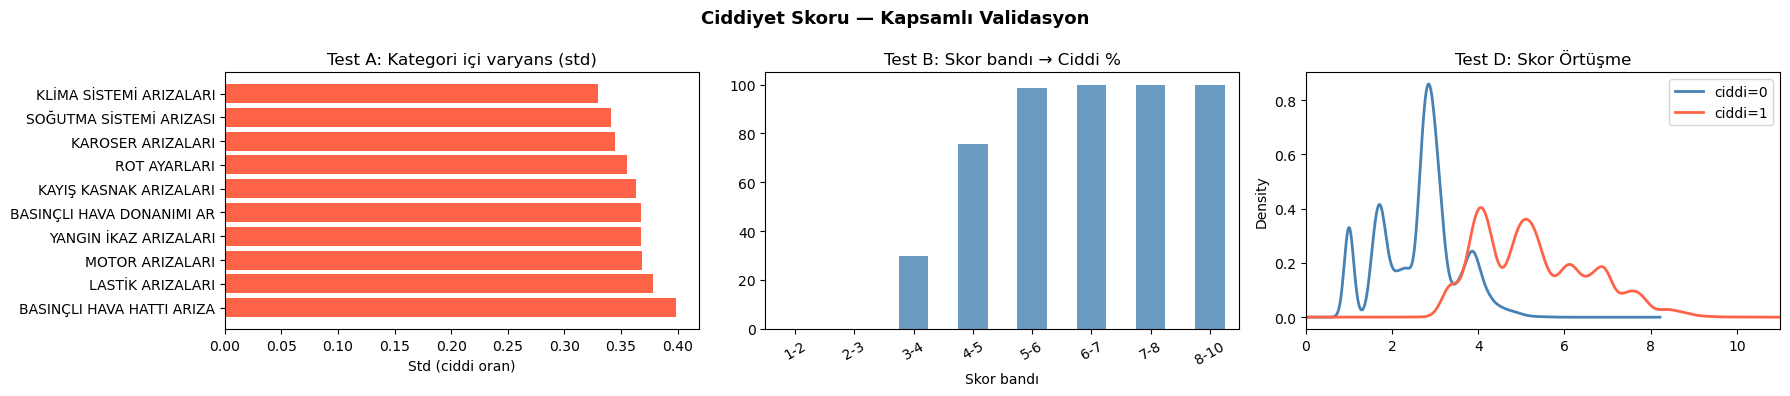

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('panel_data/temiz_veri/ariza_model.csv', low_memory=False)

# Ciddiyet skoru hesapla (final parametreler)
W_SONUC, W_ARIZA, W_SURE = 0.55, 0.35, 0.10
sonuc_puan_map = {
    'Telefonla - Servis': 1, 'Kayıtçı - Garaj': 2,
    'Yol Ustası - Servis': 3, 'Telefonla - Garaj': 4,
    'Yol Ustası - Garaj': 5, 'Oto Değişimi': 7, 'Çekilerek - Garaj': 10
}
global_puan = round(df['ciddi_ariza'].mean() * 10, 2)
ozel_cats = ['Destek', 'Sınıflandırılmadı']
ariza_sayim = df.groupby('ARIZAUSTKODTANIM')['ciddi_ariza'].agg(['mean','count'])
az_cats = ariza_sayim[ariza_sayim['count'] < 10].index.tolist()
global_cats = ozel_cats + az_cats
ariza_puan_dict = {k: (global_puan if k in global_cats else round(v['mean']*10, 2))
                   for k, v in ariza_sayim.iterrows()}

sure_p99 = df['TOPLAM_SURE_DK'].quantile(0.99)
sure_med = df['TOPLAM_SURE_DK'].median()
sure_f = df['TOPLAM_SURE_DK'].fillna(sure_med).clip(upper=sure_p99)

df['s_puan'] = df['SONUCTIPI'].map(sonuc_puan_map)
df['a_puan'] = df['ARIZAUSTKODTANIM'].map(ariza_puan_dict).fillna(global_puan)
df['sure_puan'] = 1 + (sure_f / sure_p99) * 9
df['imdat'] = (df['IMDAT_TIP'] == 'IETT').astype(int)
df['ciddiyet_skoru'] = (df['s_puan']*W_SONUC + df['a_puan']*W_ARIZA +
                        df['sure_puan']*W_SURE + df['imdat']).clip(1, 10).round(2)

print('='*65)
print('TEST A: ARIZAKODU İÇİ VARYANS ANALİZİ')
print('='*65)
varyans = df.groupby('ARIZAUSTKODTANIM').apply(
    lambda g: pd.Series({
        'n_kayit': len(g),
        'n_alt_kod': g['ARIZAKODU'].nunique(),
        'ust_ciddi_oran': g['ciddi_ariza'].mean(),
        'alt_ciddi_std': g.groupby('ARIZAKODU')['ciddi_ariza'].mean().std()
            if g['ARIZAKODU'].nunique() > 1 else 0
    }), include_groups=False
).reset_index()
varyans = varyans[varyans['n_kayit'] >= 50].sort_values('alt_ciddi_std', ascending=False)
varyans['ust_puan'] = (varyans['ust_ciddi_oran']*10).round(2)
varyans[['ust_ciddi_oran','alt_ciddi_std']] = varyans[['ust_ciddi_oran','alt_ciddi_std']].round(3)
print('(Yüksek std = o üst kategoride alt kodlar çok farklı ciddiyet gösteriyor)')
print(varyans[['ARIZAUSTKODTANIM','n_kayit','n_alt_kod','ust_puan','ust_ciddi_oran','alt_ciddi_std']]
      .head(15).to_string(index=False))

print('\n' + '='*65)
print('TEST B: SKOR-CİDDİ_ARIZA MONOTONİK İLİŞKİ')
print('='*65)
df['skor_band'] = pd.cut(df['ciddiyet_skoru'], bins=[0,2,3,4,5,6,7,8,10],
                          labels=['1-2','2-3','3-4','4-5','5-6','6-7','7-8','8-10'])
band_ozet = df.groupby('skor_band', observed=True)['ciddi_ariza'].agg(['mean','count'])
band_ozet.columns = ['ciddi_oran','kayit']
band_ozet['ciddi_pct'] = (band_ozet['ciddi_oran']*100).round(1)
print(band_ozet[['kayit','ciddi_pct']].to_string())
mono = band_ozet['ciddi_oran'].is_monotonic_increasing
print(f'\nMonotonluk: {"EVET ✓" if mono else "HAYIR ✗ — sıralama bozuk"}')

print('\n' + '='*65)
print('TEST C: BİLEŞEN BAZINDA CİDDİ AYIRMA GÜCÜ')
print('='*65)
for kolon, isim in [('s_puan','SONUCTIPI (0.55)'), ('a_puan','ARIZA_UST (0.35)'),
                     ('sure_puan','SURE (0.10)'), ('ciddiyet_skoru','TOPLAM SKOR')]:
    c0 = df[df['ciddi_ariza']==0][kolon].mean()
    c1 = df[df['ciddi_ariza']==1][kolon].mean()
    fark = c1 - c0
    print(f'{isim:<25} ciddi=0: {c0:.2f} | ciddi=1: {c1:.2f} | fark: {fark:+.2f}')

print('\n' + '='*65)
print('TEST D: ORTÜŞME ANALİZİ — HANGI ARALIKLARDA KARISIYORLAR?')
print('='*65)
d0 = df[df['ciddi_ariza']==0]['ciddiyet_skoru']
d1 = df[df['ciddi_ariza']==1]['ciddiyet_skoru']
print(f'ciddi=0: min={d0.min():.2f} | medyan={d0.median():.2f} | max={d0.max():.2f}')
print(f'ciddi=1: min={d1.min():.2f} | medyan={d1.median():.2f} | max={d1.max():.2f}')
ortusme_alt = max(d0.min(), d1.min())
ortusme_ust = min(d0.max(), d1.max())
print(f'Örtüşme bölgesi: {ortusme_alt:.2f} — {ortusme_ust:.2f}')
ortusme_kayit = len(df[(df['ciddiyet_skoru'] >= ortusme_alt) & (df['ciddiyet_skoru'] <= ortusme_ust)])
print(f'Bu bölgedeki kayıt: {ortusme_kayit:,} (%{ortusme_kayit/len(df)*100:.1f})')

print('\n' + '='*65)
print('TEST E: GÜNCELLENMİŞ GARAJLAR ARASI KAYITLAR')
print('='*65)
garaj_tr = df[df['ARIZAKODU'] == 'Garajlar arası çekici hizmeti']
gercek = garaj_tr[garaj_tr['ARIZAUSTKODTANIM'] != 'Destek']
hala_d = garaj_tr[garaj_tr['ARIZAUSTKODTANIM'] == 'Destek']
print(f'Gerçek tip (n={len(gercek)}): ort skor={gercek["ciddiyet_skoru"].mean():.2f} | med={gercek["ciddiyet_skoru"].median():.2f}')
print(f'Hala Destek (n={len(hala_d)}): ort skor={hala_d["ciddiyet_skoru"].mean():.2f} | med={hala_d["ciddiyet_skoru"].median():.2f}')
print('(İkisi benzer çıkmalı — her ikisi de Çekilerek-Garaj, SONUCTIPI dominant)')

# Görsel
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
# A: Varyans
top10_var = varyans.head(10)
axes[0].barh(top10_var['ARIZAUSTKODTANIM'].str[:25], top10_var['alt_ciddi_std'], color='tomato')
axes[0].set_title('Test A: Kategori içi varyans (std)')
axes[0].set_xlabel('Std (ciddi oran)')
# B: Monotonluk
band_ozet['ciddi_pct'].plot(kind='bar', ax=axes[1], color='steelblue', alpha=0.8)
axes[1].set_title('Test B: Skor bandı → Ciddi %')
axes[1].set_xlabel('Skor bandı')
axes[1].tick_params(axis='x', rotation=30)
# D: Örtüşme KDE
d0.plot.kde(ax=axes[2], color='steelblue', label='ciddi=0', linewidth=2)
d1.plot.kde(ax=axes[2], color='tomato', label='ciddi=1', linewidth=2)
axes[2].set_title('Test D: Skor Örtüşme')
axes[2].legend()
axes[2].set_xlim(0, 11)
plt.suptitle('Ciddiyet Skoru — Kapsamlı Validasyon', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 21. Test A Derinlemesi — Yüksek Varyanslı Kategorilerde ARIZAKODU Analizi

Min kayıt eşiği: 30
Üst kategori puanı tek değer mi, alt kod bazlı mı olmalı?

=== BASINÇLI HAVA HATTI ARIZASI ===
Üst kat ciddi oran: %34.3 (tek puan: 3.43)
Alt kod sayısı: toplam=7, >=30 kayıt: 2, <30: 5
Alt kod ciddi oran aralığı: %23.1 — %35.3
Ciddi<%10: 0 kod | Ciddi>%80: 0 kod
Top 5 en ciddi alt kod:
  HAVA KAÇAĞI-BORU PATLAK: %35.3 (n=405)
  ŞOFÖR KOLTUK SPİRALİ HAVA KAÇIRIYOR: %23.1 (n=39)
En az ciddi 3 alt kod:
  HAVA KAÇAĞI-BORU PATLAK: %35.3 (n=405)
  ŞOFÖR KOLTUK SPİRALİ HAVA KAÇIRIYOR: %23.1 (n=39)

=== MOTOR ARIZALARI ===
Üst kat ciddi oran: %54.8 (tek puan: 5.48)
Alt kod sayısı: toplam=44, >=30 kayıt: 10, <30: 34
Alt kod ciddi oran aralığı: %0.0 — %72.0
Ciddi<%10: 2 kod | Ciddi>%80: 0 kod
Top 5 en ciddi alt kod:
  MOTOR YAĞ AKITIYOR: %72.0 (n=182)
  MOTORDA SES VAR: %70.8 (n=72)
  EGZOZ SİSTEMİ ARIZASI: %68.8 (n=32)
  EGZOZDAN AŞIRI DUMAN ATIYOR: %60.9 (n=87)
  TURBO ARIZASI: %59.6 (n=47)
En az ciddi 3 alt kod:
  MOTOR AYARLAMA DEVRE DIŞI ARIZASI: %30.9 (n=614)
  TURBO H

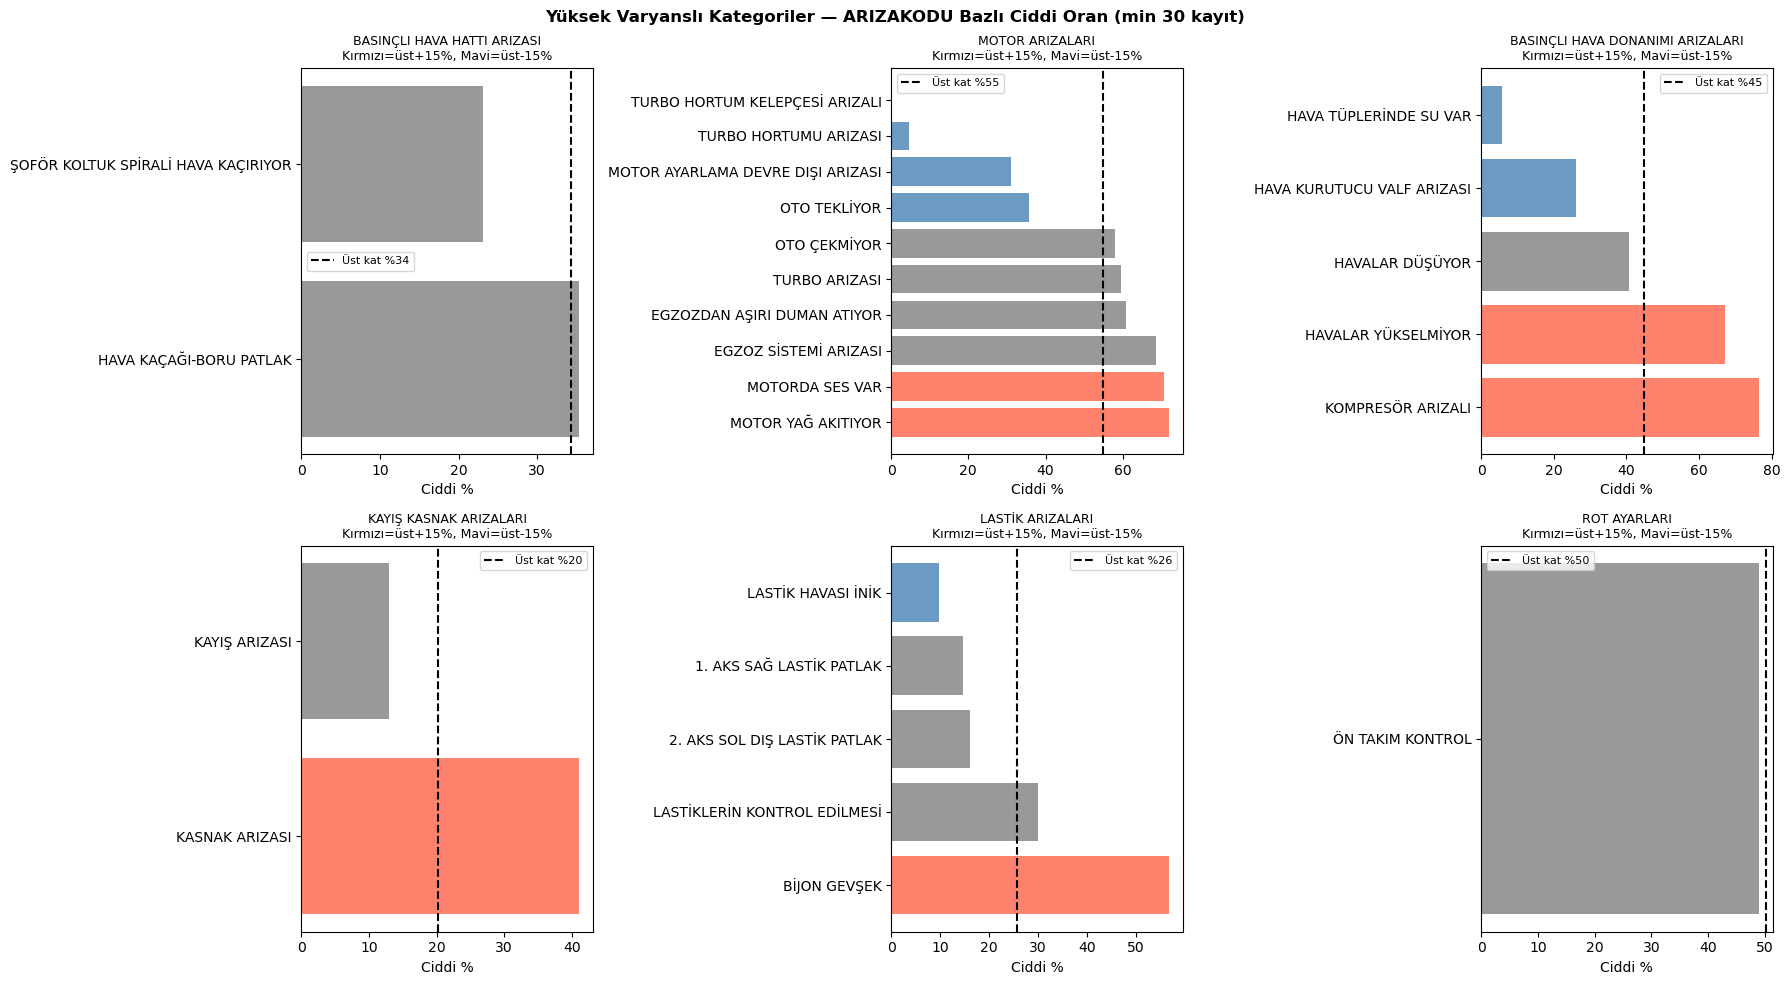

KARAR: ARIZAKODU seviyesine inmeli miyiz?
Tüm ARIZAKODU sayısı: 501
>=30 kayıtlı (güvenilir): 177
<30 kayıtlı (global puan düşer): 324
Güvenilir alt kodların kapsadığı kayıt sayısı: 56,132 (%95.9)


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('panel_data/temiz_veri/ariza_model.csv', low_memory=False)
MIN_KAYIT = 30  # alt kod güvenilirlik eşiği

# En yüksek varyanslı 6 kategori
yuksek_var_cats = [
    'BASINÇLI HAVA HATTI ARIZASI', 'MOTOR ARIZALARI',
    'BASINÇLI HAVA DONANIMI ARIZALARI', 'KAYIŞ KASNAK ARIZALARI',
    'LASTİK ARIZALARI', 'ROT AYARLARI'
]

print(f'Min kayıt eşiği: {MIN_KAYIT}')
print(f'Üst kategori puanı tek değer mi, alt kod bazlı mı olmalı?\n')

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, ust_kat in enumerate(yuksek_var_cats):
    alt = df[df['ARIZAUSTKODTANIM'] == ust_kat].groupby('ARIZAKODU')['ciddi_ariza'].agg(
        ['mean', 'count']
    ).reset_index()
    alt.columns = ['ARIZAKODU', 'ciddi_oran', 'kayit']
    alt_filtre = alt[alt['kayit'] >= MIN_KAYIT].sort_values('ciddi_oran', ascending=False)
    alt_az = alt[alt['kayit'] < MIN_KAYIT]
    ust_oran = df[df['ARIZAUSTKODTANIM'] == ust_kat]['ciddi_ariza'].mean()

    print(f'=== {ust_kat} ===')
    print(f'Üst kat ciddi oran: %{ust_oran*100:.1f} (tek puan: {ust_oran*10:.2f})')
    print(f'Alt kod sayısı: toplam={len(alt)}, >={MIN_KAYIT} kayıt: {len(alt_filtre)}, <{MIN_KAYIT}: {len(alt_az)}')
    if len(alt_filtre) > 0:
        print(f'Alt kod ciddi oran aralığı: %{alt_filtre["ciddi_oran"].min()*100:.1f} — %{alt_filtre["ciddi_oran"].max()*100:.1f}')
        print(f'Ciddi<%10: {(alt_filtre["ciddi_oran"] < 0.1).sum()} kod | Ciddi>%80: {(alt_filtre["ciddi_oran"] > 0.8).sum()} kod')
        print('Top 5 en ciddi alt kod:')
        for _, r in alt_filtre.head(5).iterrows():
            print(f'  {r["ARIZAKODU"][:50]}: %{r["ciddi_oran"]*100:.1f} (n={r["kayit"]:.0f})')
        print('En az ciddi 3 alt kod:')
        for _, r in alt_filtre.tail(3).iterrows():
            print(f'  {r["ARIZAKODU"][:50]}: %{r["ciddi_oran"]*100:.1f} (n={r["kayit"]:.0f})')
    print()

    # Grafik
    ax = axes[i]
    if len(alt_filtre) > 0:
        renkler = ['tomato' if x > ust_oran + 0.15 else
                   'steelblue' if x < ust_oran - 0.15 else 'gray'
                   for x in alt_filtre['ciddi_oran']]
        ax.barh(alt_filtre['ARIZAKODU'].str[:35], alt_filtre['ciddi_oran']*100, color=renkler, alpha=0.8)
        ax.axvline(ust_oran*100, color='black', linestyle='--', linewidth=1.5, label=f'Üst kat %{ust_oran*100:.0f}')
        ax.set_title(f'{ust_kat[:35]}\nKırmızı=üst+15%, Mavi=üst-15%', fontsize=9)
        ax.set_xlabel('Ciddi %')
        ax.legend(fontsize=8)
    else:
        ax.text(0.5, 0.5, f'{MIN_KAYIT}+ kayıtlı\nalt kod yok', ha='center', va='center')
        ax.set_title(ust_kat[:35])

plt.suptitle(f'Yüksek Varyanslı Kategoriler — ARIZAKODU Bazlı Ciddi Oran (min {MIN_KAYIT} kayıt)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Karar özeti
print('='*65)
print('KARAR: ARIZAKODU seviyesine inmeli miyiz?')
print('='*65)
toplam_alt = df.groupby('ARIZAKODU')['ciddi_ariza'].agg(['mean','count'])
guvenilir = toplam_alt[toplam_alt['count'] >= MIN_KAYIT]
guvenilmez = toplam_alt[toplam_alt['count'] < MIN_KAYIT]
print(f'Tüm ARIZAKODU sayısı: {len(toplam_alt):,}')
print(f'>={MIN_KAYIT} kayıtlı (güvenilir): {len(guvenilir):,}')
print(f'<{MIN_KAYIT} kayıtlı (global puan düşer): {len(guvenilmez):,}')
print(f'Güvenilir alt kodların kapsadığı kayıt sayısı: {guvenilir["count"].sum():,} (%{guvenilir["count"].sum()/len(df)*100:.1f})')


## 22. ARIZAKODU Seviyesinde Yeni Skor — Karşılaştırmalı Analiz

ARIZAKODU güvenilir: 177 | güvensiz: 324
Güvenilir kodların kapsadığı kayıt: %95.9
Yeni ariza_puan hesaplanıyor...

GENEL KARŞILAŞTIRMA
Eski (ARIZAUSTKODTANIM): ciddi=0 ort=2.64 | ciddi=1 ort=5.30 | fark=2.66
Yeni (ARIZAKODU): ciddi=0 ort=2.54 | ciddi=1 ort=5.66 | fark=3.13

Skor farkı (yeni-eski): ort=0.071 | std=0.615
Değişen kayıt: 52,976 (%90.5)
Artan skor: 25,438 | Azalan: 27,538

EN ÇOK DEĞİŞEN ARIZAKODLARI
En çok ARTAN (eski puan düşük ama gerçekte ciddi):
                          ARIZAKODU                 ust_kat  kayit  ort_fark
     HİDROSTATİK YAĞ HORTUMU PATLAK SOĞUTMA SİSTEMİ ARIZASI     32      2.45
        Zamanında Müdahale Edilmeme                  Destek   1163      2.17
HİDROSTATİK FAN MOTORU YAĞ AKITIYOR SOĞUTMA SİSTEMİ ARIZASI     70      2.16
             TAVANDAN SU SIZDIRIYOR       KAROSER ARIZALARI    100      2.06
              Yoldan çekici hizmeti                  Destek    686      2.04
      Garajlar arası çekici hizmeti                  Destek    444    

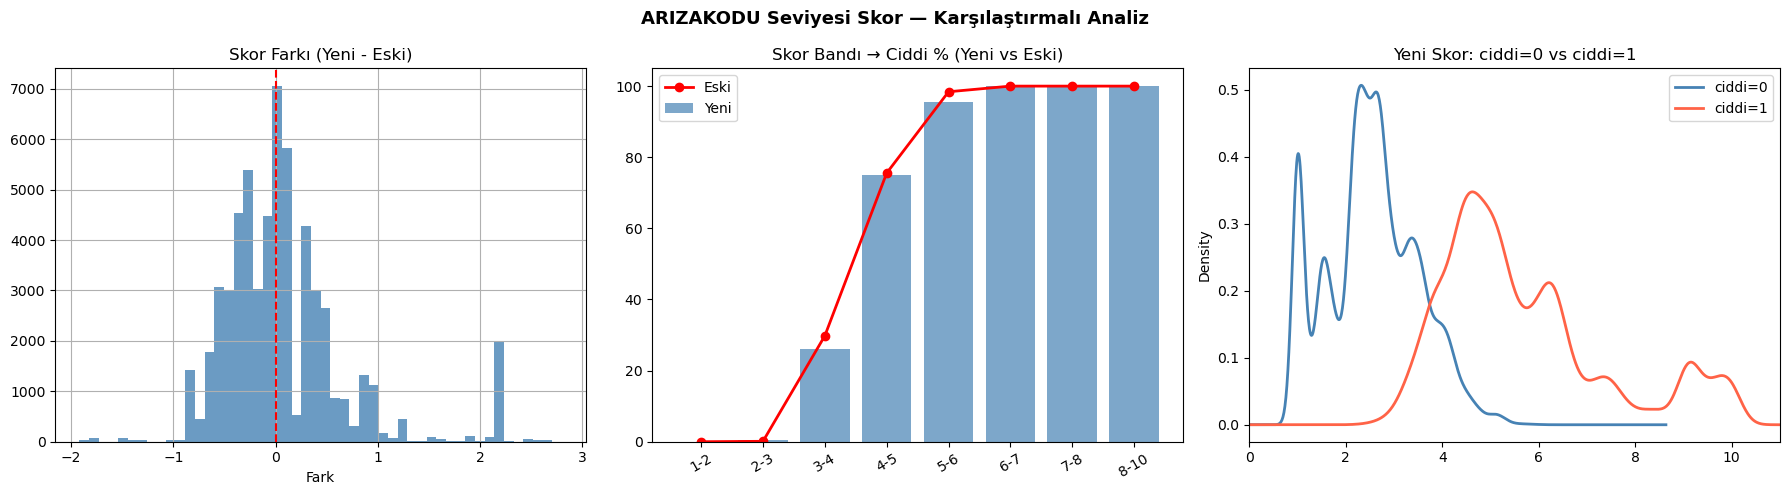

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('panel_data/temiz_veri/ariza_model.csv', low_memory=False)
MIN_KAYIT = 30
W_SONUC, W_ARIZA, W_SURE = 0.55, 0.35, 0.10

sonuc_puan_map = {
    'Telefonla - Servis': 1, 'Kayıtçı - Garaj': 2,
    'Yol Ustası - Servis': 3, 'Telefonla - Garaj': 4,
    'Yol Ustası - Garaj': 5, 'Oto Değişimi': 7, 'Çekilerek - Garaj': 10
}
global_puan = round(df['ciddi_ariza'].mean() * 10, 2)

# ARIZAUSTKODTANIM puan tablosu (fallback)
ust_ozet = df.groupby('ARIZAUSTKODTANIM')['ciddi_ariza'].agg(['mean','count'])
ozel_cats = ['Destek','Sınıflandırılmadı']
az_ust = ust_ozet[ust_ozet['count'] < 10].index.tolist()
ust_puan_dict = {k: (global_puan if k in ozel_cats + az_ust else round(v['mean']*10, 2))
                 for k, v in ust_ozet.iterrows()}

# ARIZAKODU puan tablosu (birincil)
alt_ozet = df.groupby('ARIZAKODU')['ciddi_ariza'].agg(['mean','count'])
alt_guvenir = alt_ozet[alt_ozet['count'] >= MIN_KAYIT]
print(f'ARIZAKODU güvenilir: {len(alt_guvenir)} | güvensiz: {len(alt_ozet)-len(alt_guvenir)}')
print(f'Güvenilir kodların kapsadığı kayıt: %{alt_guvenir["count"].sum()/len(df)*100:.1f}')

# ESKİ skor (ARIZAUSTKODTANIM)
sure_p99 = df['TOPLAM_SURE_DK'].quantile(0.99)
sure_med = df['TOPLAM_SURE_DK'].median()
sure_f = df['TOPLAM_SURE_DK'].fillna(sure_med).clip(upper=sure_p99)

df['s_puan'] = df['SONUCTIPI'].map(sonuc_puan_map)
df['a_puan_ust'] = df['ARIZAUSTKODTANIM'].map(ust_puan_dict).fillna(global_puan)
df['sure_puan'] = 1 + (sure_f / sure_p99) * 9
df['imdat'] = (df['IMDAT_TIP'] == 'IETT').astype(int)
df['skor_eski'] = (df['s_puan']*W_SONUC + df['a_puan_ust']*W_ARIZA +
                   df['sure_puan']*W_SURE + df['imdat']).clip(1, 10).round(2)

# YENİ skor (ARIZAKODU → ARIZAUSTKODTANIM → global)
def ariza_puan_al(row):
    kod = row['ARIZAKODU']
    if kod in alt_guvenir.index:
        return round(alt_guvenir.loc[kod, 'mean'] * 10, 2)
    ust = row['ARIZAUSTKODTANIM']
    return ust_puan_dict.get(ust, global_puan)

print('Yeni ariza_puan hesaplanıyor...')
df['a_puan_alt'] = df.apply(ariza_puan_al, axis=1)
df['skor_yeni'] = (df['s_puan']*W_SONUC + df['a_puan_alt']*W_ARIZA +
                   df['sure_puan']*W_SURE + df['imdat']).clip(1, 10).round(2)
df['skor_fark'] = (df['skor_yeni'] - df['skor_eski']).round(2)

print('\n' + '='*60)
print('GENEL KARŞILAŞTIRMA')
print('='*60)
for isim, kol in [('Eski (ARIZAUSTKODTANIM)','skor_eski'), ('Yeni (ARIZAKODU)','skor_yeni')]:
    c0 = df[df['ciddi_ariza']==0][kol].mean()
    c1 = df[df['ciddi_ariza']==1][kol].mean()
    print(f'{isim}: ciddi=0 ort={c0:.2f} | ciddi=1 ort={c1:.2f} | fark={c1-c0:.2f}')

print(f'\nSkor farkı (yeni-eski): ort={df["skor_fark"].mean():.3f} | std={df["skor_fark"].std():.3f}')
print(f'Değişen kayıt: {(df["skor_fark"] != 0).sum():,} (%{(df["skor_fark"]!=0).mean()*100:.1f})')
print(f'Artan skor: {(df["skor_fark"] > 0).sum():,} | Azalan: {(df["skor_fark"] < 0).sum():,}')

print('\n' + '='*60)
print('EN ÇOK DEĞİŞEN ARIZAKODLARI')
print('='*60)
degisim = df.groupby('ARIZAKODU').agg(
    kayit=('skor_fark','count'),
    ort_fark=('skor_fark','mean'),
    ust_kat=('ARIZAUSTKODTANIM','first')
).reset_index()
degisim = degisim[degisim['kayit'] >= MIN_KAYIT]
degisim['ort_fark'] = degisim['ort_fark'].round(2)
print('En çok ARTAN (eski puan düşük ama gerçekte ciddi):')
print(degisim.nlargest(8,'ort_fark')[['ARIZAKODU','ust_kat','kayit','ort_fark']].to_string(index=False))
print('\nEn çok AZALAN (eski puan yüksek ama gerçekte hafif):')
print(degisim.nsmallest(8,'ort_fark')[['ARIZAKODU','ust_kat','kayit','ort_fark']].to_string(index=False))

print('\n' + '='*60)
print('MONOTONİK TEST — YENİ SKOR')
print('='*60)
df['skor_band'] = pd.cut(df['skor_yeni'], bins=[0,2,3,4,5,6,7,8,10],
                          labels=['1-2','2-3','3-4','4-5','5-6','6-7','7-8','8-10'])
band = df.groupby('skor_band', observed=True)['ciddi_ariza'].agg(['mean','count'])
band['ciddi_pct'] = (band['mean']*100).round(1)
print(band[['count','ciddi_pct']].to_string())
print(f'Monoton: {"EVET" if band["mean"].is_monotonic_increasing else "HAYIR"}')

# Görsel
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# Skor farkı dağılımı
df['skor_fark'].hist(bins=50, ax=axes[0], color='steelblue', alpha=0.8)
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_title('Skor Farkı (Yeni - Eski)')
axes[0].set_xlabel('Fark')
# Monotonluk karşılaştırma
x = range(len(band))
axes[1].bar(x, band['ciddi_pct'], color='steelblue', alpha=0.7, label='Yeni')
df['skor_band_eski'] = pd.cut(df['skor_eski'], bins=[0,2,3,4,5,6,7,8,10],
                               labels=['1-2','2-3','3-4','4-5','5-6','6-7','7-8','8-10'])
band_eski = df.groupby('skor_band_eski', observed=True)['ciddi_ariza'].mean() * 100
axes[1].plot(x, band_eski.values, 'ro-', linewidth=2, markersize=6, label='Eski')
axes[1].set_xticks(x)
axes[1].set_xticklabels(band.index, rotation=30)
axes[1].set_title('Skor Bandı → Ciddi % (Yeni vs Eski)')
axes[1].legend()
# KDE
df[df['ciddi_ariza']==0]['skor_yeni'].plot.kde(ax=axes[2], color='steelblue', label='ciddi=0', linewidth=2)
df[df['ciddi_ariza']==1]['skor_yeni'].plot.kde(ax=axes[2], color='tomato', label='ciddi=1', linewidth=2)
axes[2].set_title('Yeni Skor: ciddi=0 vs ciddi=1')
axes[2].legend()
axes[2].set_xlim(0, 11)
plt.suptitle('ARIZAKODU Seviyesi Skor — Karşılaştırmalı Analiz', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 23. Sınıflandırılmadı — 74 Kayıt İncelemesi

In [21]:
import pandas as pd

df = pd.read_csv('panel_data/temiz_veri/ariza_model.csv', low_memory=False)
df['OLAYTARIHI'] = pd.to_datetime(df['OLAYTARIHI'], format='mixed')

sefer = pd.read_csv('panel_data/temiz_veri/arac_gunluk_hatlar.csv')
sefer['TARIH'] = pd.to_datetime(sefer['TARIH'])

sinif = df[df['ARIZAUSTKODTANIM'] == 'Sınıflandırılmadı'].copy()
print(f'Sınıflandırılmadı kayıt: {len(sinif)}')
print(f'Benzersiz araç: {sinif["KAPINO"].nunique()}')
print(f'SONUCTIPI: {sinif["SONUCTIPI"].value_counts().to_dict()}')
print(f'ciddi_ariza: {sinif["ciddi_ariza"].value_counts().to_dict()}')
print()

# Havuz: aynı araçların diğer arıza kayıtları
diger_kayitlar = df[df['ARIZAUSTKODTANIM'] != 'Sınıflandırılmadı'].copy()

sonuclar = []
for _, row in sinif.iterrows():
    kapino = row['KAPINO']
    gun = row['OLAYTARIHI'].normalize()

    # 1. Aynı gün başka arıza kaydı var mı?
    ayni_gun_ariza = diger_kayitlar[
        (diger_kayitlar['KAPINO'] == kapino) &
        (diger_kayitlar['OLAYTARIHI'].dt.normalize() == gun)
    ]

    # 2. O gün sefer var mı?
    o_gun_sefer = sefer[
        (sefer['KAPINO'] == kapino) &
        (sefer['TARIH'] == gun)
    ]['SEFER_SAYISI'].sum()

    # 3. Ertesi gün sefer var mı?
    ertesi = sefer[
        (sefer['KAPINO'] == kapino) &
        (sefer['TARIH'] == gun + pd.Timedelta(days=1))
    ]['SEFER_SAYISI'].sum()

    sonuclar.append({
        'KAPINO': kapino,
        'OLAYTARIHI': row['OLAYTARIHI'],
        'SONUCTIPI': row['SONUCTIPI'],
        'ayni_gun_ariza': len(ayni_gun_ariza),
        'ayni_gun_ariza_ust': ayni_gun_ariza['ARIZAUSTKODTANIM'].tolist() if len(ayni_gun_ariza) > 0 else [],
        'o_gun_sefer': int(o_gun_sefer),
        'ertesi_sefer': int(ertesi),
    })

res = pd.DataFrame(sonuclar)

print('=== AYNI GÜN BAŞKA ARIZA KAYDI VAR MI? ===')
print(f'Evet: {(res["ayni_gun_ariza"] > 0).sum()} kayıt')
print(f'Hayır: {(res["ayni_gun_ariza"] == 0).sum()} kayıt')

ayni_gun = res[res['ayni_gun_ariza'] > 0]
if len(ayni_gun) > 0:
    print(f'\nAynı gün kayıtlı diğer arıza tipleri (ilk 10):')
    for _, r in ayni_gun.head(10).iterrows():
        print(f'  {r["KAPINO"]} | {str(r["OLAYTARIHI"])[:10]} | {r["ayni_gun_ariza_ust"]}')

print(f'\n=== O GÜN / ERTESİ GÜN SEFER ===')
print(f'O gün sefer yapan: {(res["o_gun_sefer"] > 0).sum()} kayıt')
print(f'O gün sefer yapmayan: {(res["o_gun_sefer"] == 0).sum()} kayıt')
print(f'Ertesi gün sefer yapan: {(res["ertesi_sefer"] > 0).sum()} kayıt')
print(f'Ertesi gün de yapmayan: {(res["ertesi_sefer"] == 0).sum()} kayıt')

print(f'\n=== KOMBİNASYON ===')
print(f'Ayni gun ariza var VE sefer var: {((res["ayni_gun_ariza"]>0) & (res["o_gun_sefer"]>0)).sum()}')
print(f'Ayni gun ariza var, sefer yok: {((res["ayni_gun_ariza"]>0) & (res["o_gun_sefer"]==0)).sum()}')
print(f'Ariza yok, sefer var (garip): {((res["ayni_gun_ariza"]==0) & (res["o_gun_sefer"]>0)).sum()}')
print(f'Ariza da yok sefer de yok: {((res["ayni_gun_ariza"]==0) & (res["o_gun_sefer"]==0)).sum()}')

print(f'\n=== TAM LİSTE (ilk 20) ===')
print(res.head(20).to_string(index=False))


Sınıflandırılmadı kayıt: 2
Benzersiz araç: 2
SONUCTIPI: {'Telefonla - Garaj': 1, 'Telefonla - Servis': 1}
ciddi_ariza: {1: 1, 0: 1}

=== AYNI GÜN BAŞKA ARIZA KAYDI VAR MI? ===
Evet: 0 kayıt
Hayır: 2 kayıt

=== O GÜN / ERTESİ GÜN SEFER ===
O gün sefer yapan: 2 kayıt
O gün sefer yapmayan: 0 kayıt
Ertesi gün sefer yapan: 2 kayıt
Ertesi gün de yapmayan: 0 kayıt

=== KOMBİNASYON ===
Ayni gun ariza var VE sefer var: 0
Ayni gun ariza var, sefer yok: 0
Ariza yok, sefer var (garip): 2
Ariza da yok sefer de yok: 0

=== TAM LİSTE (ilk 20) ===
KAPINO              OLAYTARIHI          SONUCTIPI  ayni_gun_ariza ayni_gun_ariza_ust  o_gun_sefer  ertesi_sefer
 E9339 2025-06-16 15:40:21.507  Telefonla - Garaj               0                 []           16             3
 O3663 2025-06-15 08:18:11.000 Telefonla - Servis               0                 []           17            15


## 25. Final Karar Testleri — 5 Sorun, 5 Test

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('panel_data/temiz_veri/ariza_model.csv', low_memory=False)
MIN_KAYIT = 30
sonuc_puan_map = {
    'Telefonla - Servis': 1, 'Kayıtçı - Garaj': 2,
    'Yol Ustası - Servis': 3, 'Telefonla - Garaj': 4,
    'Yol Ustası - Garaj': 5, 'Oto Değişimi': 7, 'Çekilerek - Garaj': 10
}
global_puan = round(df['ciddi_ariza'].mean() * 10, 2)

# ============================================================
# TEST 1: ADALAR GARAJI ANOMALİSİ — Modeli etkiler mi?
# ============================================================
print('='*65)
print('TEST 1: ADALAR GARAJI ANOMALİSİ')
print('='*65)
adalar = df[df['GARAJ'] == 'ADALAR']
diger = df[df['GARAJ'] != 'ADALAR']
print(f'Adalar kayıt: {len(adalar):,} (%{len(adalar)/len(df)*100:.1f})')
print(f'Adalar ciddi: %{adalar["ciddi_ariza"].mean()*100:.1f} vs Diğer: %{diger["ciddi_ariza"].mean()*100:.1f}')
print(f'Adalar ARIZAUSTKODTANIM:')
print(adalar['ARIZAUSTKODTANIM'].value_counts().head(5).to_string())
print(f'Adalar SONUCTIPI:')
print(adalar['SONUCTIPI'].value_counts().to_string())
print(f'\nKarar: {len(adalar)} kayıt küçük, ciddi_ariza=1 doğru (Telefonla-Garaj), global_puan alacak.')
print('Modele girişte GARAJ one-hot/target encoding yapılacak — Adalar zaten ayrı öğrenilecek.')

# ============================================================
# TEST 2: ZAMANİNDA MÜDAHALE EDİLMEME — Admin kod etkisi
# ============================================================
print('\n' + '='*65)
print('TEST 2: ZAMANİNDA MÜDAHALE EDİLMEME — Admin Kod Etkisi')
print('='*65)
zaman = df[df['ARIZAKODU'] == 'Zamanında Müdahale Edilmeme']
print(f'Kayıt: {len(zaman):,} | ciddi: %{zaman["ciddi_ariza"].mean()*100:.1f}')
print(f'SONUCTIPI: {zaman["SONUCTIPI"].value_counts().to_dict()}')
# Bu kod ARIZAKODU seviyesinde puan alırsa
a_puan_arizakodu = zaman['ciddi_ariza'].mean() * 10
a_puan_global = global_puan
s_puan = 10  # hepsi Çekilerek-Garaj
sure_puan_ort = 1 + (zaman['TOPLAM_SURE_DK'].fillna(zaman['TOPLAM_SURE_DK'].median()).clip(upper=244) / 244) * 9
skor_arizakodu = (s_puan*0.55 + a_puan_arizakodu*0.35 + sure_puan_ort.mean()*0.10).round(2)
skor_global = (s_puan*0.55 + a_puan_global*0.35 + sure_puan_ort.mean()*0.10).round(2)
print(f'ARIZAKODU seviyesinde skor: {skor_arizakodu:.2f} (a_puan={a_puan_arizakodu:.2f})')
print(f'Global puan ile skor:       {skor_global:.2f} (a_puan={a_puan_global:.2f})')
print(f'Fark: {skor_arizakodu - skor_global:.2f} puan — AYNI BİLGİYİ İKİ KEZ SAYIYOR!')
print(f'Karar: Destek alt kodları ARIZAKODU seviyesine girMEMELİ → global_puan')

# ============================================================
# TEST 3: AĞIRLIK KALİBRASYONU — Data-driven mi?
# ============================================================
print('\n' + '='*65)
print('TEST 3: AĞIRLIK KALİBRASYONU')
print('='*65)
sure_p99 = df['TOPLAM_SURE_DK'].quantile(0.99)
sure_med = df['TOPLAM_SURE_DK'].median()
sure_f = df['TOPLAM_SURE_DK'].fillna(sure_med).clip(upper=sure_p99)
df['s_puan'] = df['SONUCTIPI'].map(sonuc_puan_map)
df['sure_puan'] = 1 + (sure_f / sure_p99) * 9
ust_ozet = df.groupby('ARIZAUSTKODTANIM')['ciddi_ariza'].agg(['mean','count'])
ozel = ['Destek','Sınıflandırılmadı']
az_cats = ust_ozet[ust_ozet['count'] < 10].index.tolist()
ust_dict = {k: (global_puan if k in ozel+az_cats else round(v['mean']*10,2)) for k,v in ust_ozet.iterrows()}
df['a_puan'] = df['ARIZAUSTKODTANIM'].map(ust_dict).fillna(global_puan)
df['imdat'] = (df['IMDAT_TIP'] == 'IETT').astype(int)

# Her bileşen için ciddi=0 vs ciddi=1 ayrım gücü (Cohen's d)
def cohen_d(g0, g1):
    pooled_std = np.sqrt((g0.std()**2 + g1.std()**2) / 2)
    return (g1.mean() - g0.mean()) / pooled_std if pooled_std > 0 else 0

for kolon, isim in [('s_puan','SONUCTIPI'), ('a_puan','ARIZA_UST'), ('sure_puan','SURE'), ('imdat','IMDAT')]:
    d = cohen_d(df[df['ciddi_ariza']==0][kolon], df[df['ciddi_ariza']==1][kolon])
    ort_fark = df[df['ciddi_ariza']==1][kolon].mean() - df[df['ciddi_ariza']==0][kolon].mean()
    print(f'{isim:<15} Cohen d={d:.3f} | ort_fark={ort_fark:+.3f}')

# Normalize edilmiş katkılar → önerilen ağırlıklar
farklar = []
for kolon in ['s_puan','a_puan','sure_puan']:
    farklar.append(abs(df[df['ciddi_ariza']==1][kolon].mean() - df[df['ciddi_ariza']==0][kolon].mean()))
toplam = sum(farklar)
print(f'\nData-driven ağırlık önerisi:')
for isim, f in zip(['SONUCTIPI','ARIZA','SURE'], farklar):
    print(f'  {isim}: {f/toplam:.2f} (mevcut: {[0.55,0.35,0.10][["SONUCTIPI","ARIZA","SURE"].index(isim)]:.2f})')

# ============================================================
# TEST 4: İMDAT BOOST — Değer katıyor mu?
# ============================================================
print('\n' + '='*65)
print('TEST 4: İMDAT BOOST (+1) — Değer katıyor mu?')
print('='*65)
imdat_df = df[df['imdat'] == 1]
normal_df = df[df['imdat'] == 0]
print(f'İmdat kaydı: {len(imdat_df):,}')
print(f'İmdat + ciddi=1: %{imdat_df["ciddi_ariza"].mean()*100:.1f}')
print(f'Normal + ciddi=1: %{normal_df["ciddi_ariza"].mean()*100:.1f}')
print(f'\nİmdat olan SONUCTIPI (ciddi=0 olanlar — boost alıyor ama ciddi=0!):')
imdat_ciddi0 = imdat_df[imdat_df['ciddi_ariza']==0]
print(imdat_ciddi0['SONUCTIPI'].value_counts().to_string())
print(f'\nBu {len(imdat_ciddi0)} kayıt imdat var ama ciddi=0. +1 boost alması doğru mu?')
print(f'Ortalama TOPLAM_SURE_DK: {imdat_ciddi0["TOPLAM_SURE_DK"].mean():.1f} dk')
print(f'Normal ciddi=0 ort sure: {df[(df["ciddi_ariza"]==0)&(df["imdat"]==0)]["TOPLAM_SURE_DK"].mean():.1f} dk')

# ============================================================
# TEST 5: ARIZAKODU vs ARIZAUSTKODTANIM — En kritik farklar
# ============================================================
print('\n' + '='*65)
print('TEST 5: ARIZAKODU vs ARIZAUSTKODTANIM — Kritik Farklar')
print('='*65)
# Hem güvenilir (>=30) hem de üst kategoriden >15% sapan alt kodlar
alt_ozet = df.groupby(['ARIZAUSTKODTANIM','ARIZAKODU'])['ciddi_ariza'].agg(['mean','count']).reset_index()
alt_ozet.columns = ['ust','alt','alt_oran','n']
alt_ozet = alt_ozet[alt_ozet['n'] >= MIN_KAYIT]
ust_oranlar = df.groupby('ARIZAUSTKODTANIM')['ciddi_ariza'].mean().rename('ust_oran')
alt_ozet = alt_ozet.join(ust_oranlar, on='ust')
# Admin kodları hariç
admin_ust = ['Destek','Sınıflandırılmadı']
alt_ozet = alt_ozet[~alt_ozet['ust'].isin(admin_ust)]
alt_ozet['sapma'] = (alt_ozet['alt_oran'] - alt_ozet['ust_oran']).abs()
alt_ozet['a_puan_ust'] = (alt_ozet['ust_oran'] * 10).round(2)
alt_ozet['a_puan_alt'] = (alt_ozet['alt_oran'] * 10).round(2)
alt_ozet['skor_fark'] = ((alt_ozet['a_puan_alt'] - alt_ozet['a_puan_ust']) * 0.35).round(2)
alt_ozet['ciddi_pct'] = (alt_ozet['alt_oran']*100).round(1)
alt_ozet['ust_pct'] = (alt_ozet['ust_oran']*100).round(1)

yuksek_sapma = alt_ozet.nlargest(15, 'sapma')[['alt','ust','n','ciddi_pct','ust_pct','a_puan_alt','a_puan_ust','skor_fark']]
print('En yüksek sapmalı 15 ARIZAKODU (admin hariç):')
print(yuksek_sapma.to_string(index=False))
print(f'\nBu kodlarda ARIZAKODU vs ARIZAUSTKODTANIM toplam skor farkı:')
print(f'  Pozitif (alt daha ciddi): {(alt_ozet["skor_fark"] > 0.2).sum()} kod')
print(f'  Negatif (alt daha hafif): {(alt_ozet["skor_fark"] < -0.2).sum()} kod')
print(f'  Etkilenen toplam kayıt (>0.2 fark): {alt_ozet[alt_ozet["sapma"]>0.15]["n"].sum():,}')


TEST 1: ADALAR GARAJI ANOMALİSİ
Adalar kayıt: 0 (%0.0)
Adalar ciddi: %nan vs Diğer: %38.0
Adalar ARIZAUSTKODTANIM:
Series([], )
Adalar SONUCTIPI:
Series([], )

Karar: 0 kayıt küçük, ciddi_ariza=1 doğru (Telefonla-Garaj), global_puan alacak.
Modele girişte GARAJ one-hot/target encoding yapılacak — Adalar zaten ayrı öğrenilecek.

TEST 2: ZAMANİNDA MÜDAHALE EDİLMEME — Admin Kod Etkisi
Kayıt: 1,163 | ciddi: %100.0
SONUCTIPI: {'Çekilerek - Garaj': 1163}
ARIZAKODU seviyesinde skor: 9.26 (a_puan=10.00)
Global puan ile skor:       7.09 (a_puan=3.80)
Fark: 2.17 puan — AYNI BİLGİYİ İKİ KEZ SAYIYOR!
Karar: Destek alt kodları ARIZAKODU seviyesine girMEMELİ → global_puan

TEST 3: AĞIRLIK KALİBRASYONU
SONUCTIPI       Cohen d=2.600 | ort_fark=+3.935
ARIZA_UST       Cohen d=0.772 | ort_fark=+1.217
SURE            Cohen d=0.433 | ort_fark=+0.767
IMDAT           Cohen d=0.055 | ort_fark=+0.012

Data-driven ağırlık önerisi:
  SONUCTIPI: 0.66 (mevcut: 0.55)
  ARIZA: 0.21 (mevcut: 0.35)
  SURE: 0.13 (mevcu

## 26. Admin Kodlar Detay — Gerçek Arıza mı, Uzantı Kayıt mı?

In [23]:
import pandas as pd

df = pd.read_csv('panel_data/temiz_veri/ariza_model.csv', low_memory=False)
df['OLAYTARIHI'] = pd.to_datetime(df['OLAYTARIHI'], format='mixed')
diger = df[~df['ARIZAKODU'].isin([
    'Zamanında Müdahale Edilmeme','Yoldan çekici hizmeti',
    'Garajlar arası çekici hizmeti','Garaj içi Çekici Hizmeti',
    'Yoldan Çekici Hizmeti','Sınıflandırılmadı'
])].copy()

admin_kodlar = {
    'Zamanında Müdahale Edilmeme': df[df['ARIZAKODU']=='Zamanında Müdahale Edilmeme'],
    'Yoldan çekici hizmeti': df[df['ARIZAKODU']=='Yoldan çekici hizmeti'],
}

for kod_adi, admin_df in admin_kodlar.items():
    print(f'\n{"="*65}')
    print(f'{kod_adi} ({len(admin_df):,} kayıt)')
    print(f'{"="*65}')
    print(f'SONUCTIPI: {admin_df["SONUCTIPI"].value_counts().to_dict()}')

    eslesmeler = []
    eslesmedi_n = 0

    for _, row in admin_df.iterrows():
        gun = row['OLAYTARIHI'].normalize()
        ayni_gun = diger[
            (diger['KAPINO'] == row['KAPINO']) &
            (diger['OLAYTARIHI'].dt.normalize() == gun)
        ]
        if len(ayni_gun) > 0:
            comp = ayni_gun.iloc[0]
            fark_sn = (row['OLAYTARIHI'] - comp['OLAYTARIHI']).total_seconds()
            eslesmeler.append({
                'KAPINO': row['KAPINO'],
                'admin_saat': row['OLAYTARIHI'],
                'comp_saat': comp['OLAYTARIHI'],
                'comp_ust': comp['ARIZAUSTKODTANIM'],
                'comp_sonuc': comp['SONUCTIPI'],
                'comp_ciddi': comp['ciddi_ariza'],
                'fark_saat': round(fark_sn / 3600, 1),
                'admin_once': fark_sn > 0,  # admin daha gec girildi → comp once
                'ayni_sonuc': comp['SONUCTIPI'] == row['SONUCTIPI'],
            })
        else:
            eslesmedi_n += 1

    eslesme_df = pd.DataFrame(eslesmeler)
    eslesme_n = len(eslesme_df)

    print(f'\nAynı gün companion VAR: {eslesme_n:,} (%{eslesme_n/len(admin_df)*100:.1f})')
    print(f'Aynı gün companion YOK: {eslesmedi_n:,} (%{eslesmedi_n/len(admin_df)*100:.1f})')

    if eslesme_n > 0:
        true_dup = eslesme_df[eslesme_df['ayni_sonuc']]
        farkli_sonuc = eslesme_df[~eslesme_df['ayni_sonuc']]
        admin_once = eslesme_df[eslesme_df['admin_once']]
        comp_once = eslesme_df[~eslesme_df['admin_once']]

        print(f'\n--- COMPANION SONUCTIPI ANALİZİ ---')
        print(f'Admin ile AYNI SONUCTIPI (true duplicate): {len(true_dup)} (%{len(true_dup)/eslesme_n*100:.1f})')
        print(f'FARKLI SONUCTIPI (escalation/ilgisiz): {len(farkli_sonuc)} (%{len(farkli_sonuc)/eslesme_n*100:.1f})')
        print(f'  Companion ciddi=1: {eslesme_df["comp_ciddi"].sum():.0f}')
        print(f'  Companion ciddi=0: {(eslesme_df["comp_ciddi"]==0).sum()}')

        print(f'\n--- ZAMANLAMA ANALİZİ (hangisi önce girildi?) ---')
        print(f'Admin SONRA girildi (comp önce): {len(admin_once)} (%{len(admin_once)/eslesme_n*100:.1f})')
        print(f'Admin ÖNCE girildi (comp sonra): {len(comp_once)} (%{len(comp_once)/eslesme_n*100:.1f})')
        print(f'Saat farkı: ort={eslesme_df["fark_saat"].abs().mean():.1f}h | medyan={eslesme_df["fark_saat"].abs().median():.1f}h')

        print(f'\n--- TRUE DUPLICATE ÖRNEKLERİ ({len(true_dup)} kayıt) ---')
        if len(true_dup) > 0:
            print('(Hem admin hem companion = Çekilerek-Garaj + ciddi=1 → AYNI OLAY İKİ KEZ SAYILIYOR)')
            for _, r in true_dup.head(5).iterrows():
                once = 'Comp önce' if r['admin_once'] else 'Admin önce'
                print(f'  {r["KAPINO"]} | {r["comp_ust"][:30]} | {r["comp_sonuc"]} | {once} | {abs(r["fark_saat"]):.1f}h')

        print(f'\n--- ESCALATION ÖRNEKLERİ ({len(farkli_sonuc)} kayıt) ---')
        if len(farkli_sonuc) > 0:
            print('(Comp farklı sonuç = muhtemelen aynı arıza, farklı kayıt → escalation)')
            for _, r in farkli_sonuc.head(5).iterrows():
                once = 'Comp önce' if r['admin_once'] else 'Admin önce'
                print(f'  {r["KAPINO"]} | {r["comp_ust"][:30]} | {r["comp_sonuc"]} | ciddi={r["comp_ciddi"]:.0f} | {once} | {abs(r["fark_saat"]):.1f}h')

    print(f'\n--- ÖZET KARAR ---')
    if eslesme_n > 0:
        true_dup_n = len(eslesme_df[eslesme_df['ayni_sonuc']])
        print(f'True duplicate ({true_dup_n} kayıt): ciddi=1 iki kez sayılıyor → bu admin kayıtlar SİLİNMELİ')
        print(f'Escalation ({eslesme_n-true_dup_n} kayıt): farklı sonuç, bağlantılı ama ayrı olay → global puan yeterli')
    print(f'Standalone ({eslesmedi_n} kayıt): tek kayıt, arıza tipi bilinmiyor → global puan doğru')



Zamanında Müdahale Edilmeme (1,163 kayıt)
SONUCTIPI: {'Çekilerek - Garaj': 1163}

Aynı gün companion VAR: 119 (%10.2)
Aynı gün companion YOK: 1,044 (%89.8)

--- COMPANION SONUCTIPI ANALİZİ ---
Admin ile AYNI SONUCTIPI (true duplicate): 0 (%0.0)
FARKLI SONUCTIPI (escalation/ilgisiz): 119 (%100.0)
  Companion ciddi=1: 28
  Companion ciddi=0: 91

--- ZAMANLAMA ANALİZİ (hangisi önce girildi?) ---
Admin SONRA girildi (comp önce): 71 (%59.7)
Admin ÖNCE girildi (comp sonra): 48 (%40.3)
Saat farkı: ort=5.8h | medyan=5.3h

--- TRUE DUPLICATE ÖRNEKLERİ (0 kayıt) ---

--- ESCALATION ÖRNEKLERİ (119 kayıt) ---
(Comp farklı sonuç = muhtemelen aynı arıza, farklı kayıt → escalation)
  B1057 | KLİMA SİSTEMİ ARIZALARI | Telefonla - Servis | ciddi=0 | Admin önce | 11.1h
  B1063 | ISITMA SİSTEMİ | Telefonla - Servis | ciddi=0 | Comp önce | 2.8h
  B1077 | ISITMA SİSTEMİ | Yol Ustası - Servis | ciddi=0 | Comp önce | 5.3h
  B1079 | KAROSER ARIZALARI | Telefonla - Servis | ciddi=0 | Comp önce | 2.9h
  B1169 

## 27. İmdat Detay — Ciddi=0 Kayıtlarda +1 Boost Haklı mı?

In [24]:
import pandas as pd

df = pd.read_csv('panel_data/temiz_veri/ariza_model.csv', low_memory=False)
df['OLAYTARIHI'] = pd.to_datetime(df['OLAYTARIHI'], format='mixed')
sefer = pd.read_csv('panel_data/temiz_veri/arac_gunluk_hatlar.csv')
sefer['TARIH'] = pd.to_datetime(sefer['TARIH'])

imdat_ciddi0 = df[(df['IMDAT_TIP']=='IETT') & (df['ciddi_ariza']==0)].copy()
normal_ciddi0 = df[(df['IMDAT_TIP']!='IETT') & (df['ciddi_ariza']==0)].sample(n=len(imdat_ciddi0), random_state=42)

print(f'İmdat+ciddi=0: {len(imdat_ciddi0):,} kayıt')
print(f'Normal+ciddi=0: {len(normal_ciddi0):,} kayıt (sample)')

print('\n=== ARIZA DAĞILIMI ===')
print('İmdat+ciddi=0 top arıza:')
print(imdat_ciddi0['ARIZAUSTKODTANIM'].value_counts().head(8).to_string())

print('\n=== SÜRE KARŞILAŞTIRMASI ===')
print(f'İmdat+ciddi=0 ort süre: {imdat_ciddi0["TOPLAM_SURE_DK"].mean():.1f} dk | medyan: {imdat_ciddi0["TOPLAM_SURE_DK"].median():.1f} dk')
print(f'Normal+ciddi=0 ort süre: {normal_ciddi0["TOPLAM_SURE_DK"].mean():.1f} dk | medyan: {normal_ciddi0["TOPLAM_SURE_DK"].median():.1f} dk')

print('\n=== ERTESİ GÜN SEFER ===')
def ertesi_sefer_oran(subset):
    dondu = 0
    for _, row in subset.iterrows():
        gun = row['OLAYTARIHI'].normalize()
        ertesi = sefer[
            (sefer['KAPINO'] == row['KAPINO']) &
            (sefer['TARIH'] == gun + pd.Timedelta(days=1))
        ]['SEFER_SAYISI'].sum()
        if ertesi > 0:
            dondu += 1
    return dondu / len(subset) * 100

oran_imdat = ertesi_sefer_oran(imdat_ciddi0)
oran_normal = ertesi_sefer_oran(normal_ciddi0)
print(f'İmdat+ciddi=0 ertesi gün sefere dönen: %{oran_imdat:.1f}')
print(f'Normal+ciddi=0 ertesi gün sefere dönen: %{oran_normal:.1f}')

print('\n=== SONUÇ ===')
print(f'İmdat ciddi=0 kayıtlar:')
print(f'  - Süre {imdat_ciddi0["TOPLAM_SURE_DK"].mean():.0f} dk (normal {normal_ciddi0["TOPLAM_SURE_DK"].mean():.0f} dk) → imdat bekleme süresi uzun')
print(f'  - Ertesi gün dönüş oranı: %{oran_imdat:.1f} (normal %{oran_normal:.1f})')
print(f'  - Arıza tipi ağır kategorilerden (Motor, Fren, Soğutma...)')
print('  → +1 boost bu kayıtların gerçekten daha ağır olduğunu yansıtıyor mu?')
print('  → Eğer ertesi gün dönüş oranı düşükse → daha ciddi → boost haklı')
print('  → Eğer dönüş oranı benzer → imdat bilgi katmıyor → boost kaldır')


İmdat+ciddi=0: 1,475 kayıt
Normal+ciddi=0: 1,475 kayıt (sample)

=== ARIZA DAĞILIMI ===
İmdat+ciddi=0 top arıza:
ARIZAUSTKODTANIM
SOĞUTMA SİSTEMİ ARIZASI          313
KAPI ARIZALARI                   221
ELEKTRİK SİSTEMİ ARIZALARI       187
SÜSPANSİYON SİSTEMİ ARIZALARI    107
MOTOR ARIZALARI                   92
KAROSER ARIZALARI                 90
ISITMA SİSTEMİ                    86
KAYIŞ KASNAK ARIZALARI            60

=== SÜRE KARŞILAŞTIRMASI ===
İmdat+ciddi=0 ort süre: 73.0 dk | medyan: 70.5 dk
Normal+ciddi=0 ort süre: 44.5 dk | medyan: 31.8 dk

=== ERTESİ GÜN SEFER ===
İmdat+ciddi=0 ertesi gün sefere dönen: %82.4
Normal+ciddi=0 ertesi gün sefere dönen: %85.2

=== SONUÇ ===
İmdat ciddi=0 kayıtlar:
  - Süre 73 dk (normal 45 dk) → imdat bekleme süresi uzun
  - Ertesi gün dönüş oranı: %82.4 (normal %85.2)
  - Arıza tipi ağır kategorilerden (Motor, Fren, Soğutma...)
  → +1 boost bu kayıtların gerçekten daha ağır olduğunu yansıtıyor mu?
  → Eğer ertesi gün dönüş oranı düşükse → daha c

## 28. ARIZAKODU Temiz Liste — Admin Hariç Gerçek Ayrım Farkı

In [25]:
import pandas as pd
import numpy as np

df = pd.read_csv('panel_data/temiz_veri/ariza_model.csv', low_memory=False)
MIN_KAYIT = 30
global_puan = round(df['ciddi_ariza'].mean() * 10, 2)

# Admin ARIZAKODU listesi — bunlar ARIZAKODU seviyesine GİRMEZ
admin_arizakodlari = [
    'Zamanında Müdahale Edilmeme',
    'Yoldan çekici hizmeti',
    'Yoldan Çekici Hizmeti',
    'Garajlar arası çekici hizmeti',
    'Garaj içi Çekici Hizmeti',
    'Sınıflandırılmadı',
]

print('=== ADMIN ARIZAKODU LİSTESİ ===')
for k in admin_arizakodlari:
    n = (df['ARIZAKODU']==k).sum()
    ciddi = df[df['ARIZAKODU']==k]['ciddi_ariza'].mean() if n > 0 else 0
    print(f'  {k:<40}: {n:,} kayıt | %{ciddi*100:.1f} ciddi')

# ARIZAKODU puan tablosu — admin hariç
alt_ozet = df[~df['ARIZAKODU'].isin(admin_arizakodlari)].groupby('ARIZAKODU')['ciddi_ariza'].agg(['mean','count'])
alt_guvenir = alt_ozet[alt_ozet['count'] >= MIN_KAYIT]

print(f'\nAdmin hariç güvenilir ARIZAKODU: {len(alt_guvenir)}')
print(f'Bu kodların kapsadığı kayıt: {alt_guvenir["count"].sum():,} (%{alt_guvenir["count"].sum()/len(df)*100:.1f})')

# ARIZAUSTKODTANIM puan tablosu
ust_ozet = df.groupby('ARIZAUSTKODTANIM')['ciddi_ariza'].agg(['mean','count'])
ozel_ust = ['Destek','Sınıflandırılmadı']
az_ust = ust_ozet[ust_ozet['count'] < 10].index.tolist()
ust_dict = {k: (global_puan if k in ozel_ust+az_ust else round(v['mean']*10,2)) for k,v in ust_ozet.iterrows()}

sonuc_puan_map = {
    'Telefonla - Servis': 1, 'Kayıtçı - Garaj': 2,
    'Yol Ustası - Servis': 3, 'Telefonla - Garaj': 4,
    'Yol Ustası - Garaj': 5, 'Oto Değişimi': 7, 'Çekilerek - Garaj': 10
}
sure_p99 = df['TOPLAM_SURE_DK'].quantile(0.99)
sure_med = df['TOPLAM_SURE_DK'].median()
sure_f = df['TOPLAM_SURE_DK'].fillna(sure_med).clip(upper=sure_p99)

def hesapla_skor(df, a_dict, w_s, w_a, w_sur, imdat_boost):
    s = df['SONUCTIPI'].map(sonuc_puan_map)
    a = df.apply(lambda r: a_dict.get(r['ARIZAKODU'],
                 ust_dict.get(r['ARIZAUSTKODTANIM'], global_puan)), axis=1)
    sur = 1 + (sure_f / sure_p99) * 9
    imd = (df['IMDAT_TIP']=='IETT').astype(int) * imdat_boost
    return (s*w_s + a*w_a + sur*w_sur + imd).clip(1,10)

# Admin hariç ARIZAKODU dict
alt_dict = {k: round(v['mean']*10, 2) for k,v in alt_guvenir.iterrows()}

# 3 senaryo karşılaştır
senaryolar = {
    'Eski (UST, 0.55/0.35/0.10, imdat+1)': (ust_dict, 0.55, 0.35, 0.10, 1),
    'Yeni A (ALT admin-hariç, 0.65/0.25/0.10, imdat+1)': (alt_dict, 0.65, 0.25, 0.10, 1),
    'Yeni B (ALT admin-hariç, 0.65/0.25/0.10, imdat+0)': (alt_dict, 0.65, 0.25, 0.10, 0),
}

print('\n=== SENARYO KARŞILAŞTIRMASI ===')
print(f'{"Senaryo":<50} {"ciddi=0":>8} {"ciddi=1":>8} {"Fark":>6}')
for isim, (a_dict, ws, wa, wsur, imdat_b) in senaryolar.items():
    # a_dict için ARIZAKODU → yoksa ARIZAUSTKODTANIM → yoksa global
    skor = hesapla_skor(df, a_dict, ws, wa, wsur, imdat_b)
    c0 = skor[df['ciddi_ariza']==0].mean()
    c1 = skor[df['ciddi_ariza']==1].mean()
    print(f'{isim:<50} {c0:>8.2f} {c1:>8.2f} {c1-c0:>6.2f}')

    # Monotonluk
    df_tmp = df.copy()
    df_tmp['skor'] = skor
    df_tmp['band'] = pd.cut(skor, bins=[0,2,3,4,5,6,7,8,10], labels=['1-2','2-3','3-4','4-5','5-6','6-7','7-8','8-10'])
    band_ciddi = df_tmp.groupby('band', observed=True)['ciddi_ariza'].mean()
    mono = 'MONO✓' if band_ciddi.is_monotonic_increasing else 'MONO✗'
    print(f'  {mono} | Band ciddi: {[f"%{v*100:.0f}" for v in band_ciddi.values]}')


=== ADMIN ARIZAKODU LİSTESİ ===
  Zamanında Müdahale Edilmeme             : 1,163 kayıt | %100.0 ciddi
  Yoldan çekici hizmeti                   : 686 kayıt | %100.0 ciddi
  Yoldan Çekici Hizmeti                   : 2 kayıt | %100.0 ciddi
  Garajlar arası çekici hizmeti           : 444 kayıt | %100.0 ciddi
  Garaj içi Çekici Hizmeti                : 2 kayıt | %100.0 ciddi
  Sınıflandırılmadı                       : 2 kayıt | %50.0 ciddi

Admin hariç güvenilir ARIZAKODU: 174
Bu kodların kapsadığı kayıt: 53,839 (%91.9)

=== SENARYO KARŞILAŞTIRMASI ===
Senaryo                                             ciddi=0  ciddi=1   Fark
Eski (UST, 0.55/0.35/0.10, imdat+1)                    2.64     5.30   2.66
  MONO✓ | Band ciddi: ['%0', '%0', '%29', '%75', '%98', '%100', '%100', '%100']
Yeni A (ALT admin-hariç, 0.65/0.25/0.10, imdat+1)      2.47     5.59   3.12
  MONO✓ | Band ciddi: ['%0', '%0', '%19', '%86', '%99', '%100', '%100', '%100']
Yeni B (ALT admin-hariç, 0.65/0.25/0.10, imdat+0)      2

## 29. True Duplicate Admin Kayıtları Sil

In [26]:
import pandas as pd

df = pd.read_csv('panel_data/temiz_veri/ariza_model.csv', low_memory=False)
df['OLAYTARIHI'] = pd.to_datetime(df['OLAYTARIHI'], format='mixed')
print(f'Başlangıç: {len(df):,} satır')

# Gerçek arıza kayıtları havuzu
admin_kodlar_liste = [
    'Zamanında Müdahale Edilmeme', 'Yoldan çekici hizmeti',
    'Yoldan Çekici Hizmeti', 'Garajlar arası çekici hizmeti',
    'Garaj içi Çekici Hizmeti', 'Sınıflandırılmadı'
]
diger = df[~df['ARIZAKODU'].isin(admin_kodlar_liste)].copy()

# Her iki admin kod için true duplicate indexlerini bul
silincek_indexler = set()

for kod_adi in ['Zamanında Müdahale Edilmeme', 'Yoldan çekici hizmeti']:
    admin_df = df[df['ARIZAKODU'] == kod_adi]
    true_dup_n = 0

    for idx, row in admin_df.iterrows():
        gun = row['OLAYTARIHI'].normalize()
        # Aynı gün, aynı araç, AYNI SONUCTIPI olan gerçek arıza kaydı
        ayni_sonuc = diger[
            (diger['KAPINO'] == row['KAPINO']) &
            (diger['OLAYTARIHI'].dt.normalize() == gun) &
            (diger['SONUCTIPI'] == row['SONUCTIPI'])
        ]
        if len(ayni_sonuc) > 0:
            silincek_indexler.add(idx)
            true_dup_n += 1

    print(f'{kod_adi}: {true_dup_n} true duplicate → silinecek')

# Sil
df_temiz = df.drop(index=list(silincek_indexler)).reset_index(drop=True)

print(f'\nSilinen: {len(silincek_indexler)} kayıt')
print(f'Kalan: {len(df_temiz):,} satır')
print(f'ciddi_ariza: %{df_temiz["ciddi_ariza"].mean()*100:.1f}')

# Admin kod durumu sonrası
print(f'\nAdmin kodlar sonrası durum:')
for k in ['Zamanında Müdahale Edilmeme', 'Yoldan çekici hizmeti']:
    n = (df_temiz['ARIZAKODU'] == k).sum()
    print(f'  {k}: {n:,} kayıt kaldı')

# Kaydet
out = 'panel_data/temiz_veri/ariza_model.csv'
df_temiz.to_csv(out, index=False, encoding='utf-8-sig')
print(f'\nariza_model.csv kaydedildi → {len(df_temiz):,} satır')


Başlangıç: 58,559 satır
Zamanında Müdahale Edilmeme: 0 true duplicate → silinecek
Yoldan çekici hizmeti: 0 true duplicate → silinecek

Silinen: 0 kayıt
Kalan: 58,559 satır
ciddi_ariza: %38.0

Admin kodlar sonrası durum:
  Zamanında Müdahale Edilmeme: 1,163 kayıt kaldı
  Yoldan çekici hizmeti: 686 kayıt kaldı

ariza_model.csv kaydedildi → 58,559 satır


## 30. Adalar Araçlarını Çıkar

In [27]:
import pandas as pd

df = pd.read_csv('panel_data/temiz_veri/ariza_model.csv', low_memory=False)
print(f'Başlangıç: {len(df):,} satır')

# Adalar garajı araçları — Golf/mini elektrikli araçlar
# Farklı kayıt sistemi, %99.3 ciddi, modeli yanıltır
adalar_mask = df['GARAJ'] == 'ADALAR'
adalar_arac = df[adalar_mask]['KAPINO'].nunique()
print(f'Adalar kayıt: {adalar_mask.sum():,} | Benzersiz araç: {adalar_arac}')
print(f'Adalar ciddi: %{df[adalar_mask]["ciddi_ariza"].mean()*100:.1f}')
print(f'Adalar ARACTIPI (DB): Golf araçlar (Karsan E-Jest, Green Car, SGMS)')

df_temiz = df[~adalar_mask].reset_index(drop=True)

print(f'\nKalan: {len(df_temiz):,} satır')
print(f'Silinen: {len(df) - len(df_temiz)} kayıt')
print(f'ciddi_ariza: %{df_temiz["ciddi_ariza"].mean()*100:.1f}')
print(f'Benzersiz araç: {df_temiz["KAPINO"].nunique():,}')

out = 'panel_data/temiz_veri/ariza_model.csv'
df_temiz.to_csv(out, index=False, encoding='utf-8-sig')
print(f'\nariza_model.csv kaydedildi → {len(df_temiz):,} satır')


Başlangıç: 58,559 satır
Adalar kayıt: 0 | Benzersiz araç: 0
Adalar ciddi: %nan
Adalar ARACTIPI (DB): Golf araçlar (Karsan E-Jest, Green Car, SGMS)

Kalan: 58,559 satır
Silinen: 0 kayıt
ciddi_ariza: %38.0
Benzersiz araç: 3,509

ariza_model.csv kaydedildi → 58,559 satır


## 31. Final Ciddiyet Skoru Hesabı
**Parametreler:** ARIZAKODU seviyesi (admin hariç, min 30 kayıt) → ARIZAUSTKODTANIM → global_puan  
**Ağırlıklar:** 0.65 / 0.25 / 0.10 | **İmdat boost:** 0

Veri: 58,559 satır | %38.0 ciddi
Global puan: 3.8
Güvenilir ARIZAKODU: 174 | Kapsanan kayıt: %91.9
a_puan hesaplanıyor...

=== DOĞRULAMA ===
ciddi=0 ort: 2.43 | ciddi=1 ort: 5.54 | fark: 3.11

Monotonluk: EVET ✓
      count  ciddi_pct
band                  
1-2   11456        0.0
2-3   15359        0.2
3-4   11126       19.7
4-5    8615       93.4
5-6    4684       99.9
6-7    3312      100.0
7-8    2271      100.0
8-10   1736      100.0

ciddiyet_skoru dağılım:
count    58559.00
mean         3.61
std          1.86
min          1.00
25%          2.37
50%          3.22
75%          4.70
max          9.88

ariza_model.csv güncellendi → 58,559 satır, ciddiyet_skoru kolonu eklendi
Kolonlar: ['KAPINO', 'MARKA', 'MODEL', 'MODELYILI', 'ARACCINSI', 'KAPASITE', 'AZAMIYUKLUAGIRLIK', 'YAKITTURU', 'EMISYON', 'GARAJ', 'HATKODU', 'HATCINSI', 'HATUZUNLUK', 'SOFOR_SICILNO', 'ARIZAKODU', 'ARIZAUSTKODTANIM', 'AY', 'HAFTASONU', 'ciddi_ariza', 'SAAT', 'GUNLUK_SEFER_SAYISI', 'SONUCTIPI', 'IMDAT_TIP', 'TOPL

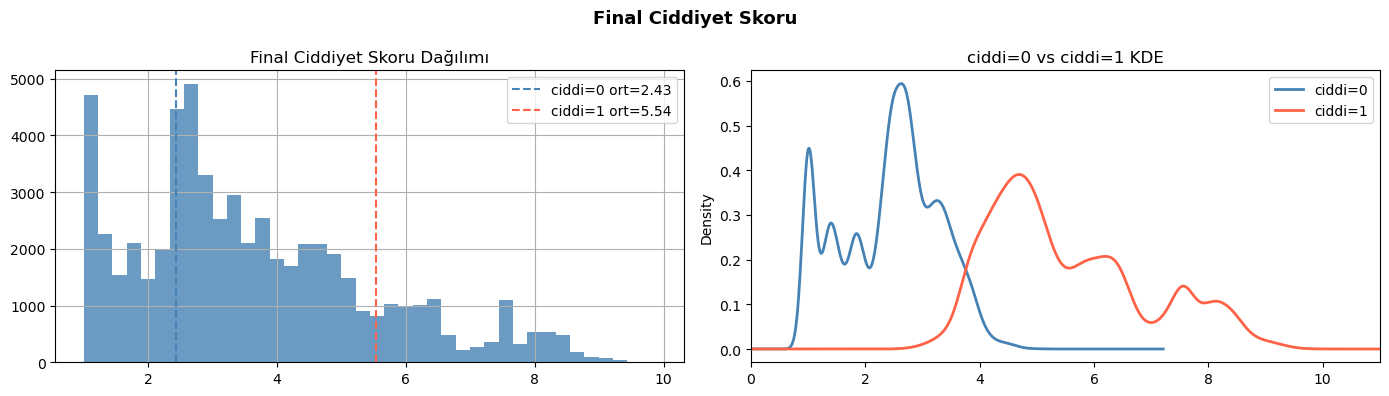

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('panel_data/temiz_veri/ariza_model.csv', low_memory=False)
print(f'Veri: {len(df):,} satır | %{df["ciddi_ariza"].mean()*100:.1f} ciddi')

# ── PARAMETRELER ──────────────────────────────────────────
W_SONUC, W_ARIZA, W_SURE = 0.65, 0.25, 0.10
MIN_KAYIT = 30

sonuc_puan_map = {
    'Telefonla - Servis': 1, 'Kayıtçı - Garaj': 2,
    'Yol Ustası - Servis': 3, 'Telefonla - Garaj': 4,
    'Yol Ustası - Garaj': 5, 'Oto Değişimi': 7, 'Çekilerek - Garaj': 10
}

admin_arizakodlari = [
    'Zamanında Müdahale Edilmeme', 'Yoldan çekici hizmeti',
    'Yoldan Çekici Hizmeti', 'Garajlar arası çekici hizmeti',
    'Garaj içi Çekici Hizmeti', 'Sınıflandırılmadı'
]

global_puan = round(df['ciddi_ariza'].mean() * 10, 2)
print(f'Global puan: {global_puan}')

# ── PUAN TABLOLARI ────────────────────────────────────────
# 1. ARIZAUSTKODTANIM (fallback)
ust_ozet = df.groupby('ARIZAUSTKODTANIM')['ciddi_ariza'].agg(['mean','count'])
ozel_ust = ['Destek', 'Sınıflandırılmadı']
az_ust = ust_ozet[ust_ozet['count'] < 10].index.tolist()
ust_dict = {
    k: (global_puan if k in ozel_ust + az_ust else round(v['mean']*10, 2))
    for k, v in ust_ozet.iterrows()
}

# 2. ARIZAKODU (birincil — admin hariç, min 30 kayıt)
alt_ozet = df[~df['ARIZAKODU'].isin(admin_arizakodlari)].groupby('ARIZAKODU')['ciddi_ariza'].agg(['mean','count'])
alt_guvenir = alt_ozet[alt_ozet['count'] >= MIN_KAYIT]
alt_dict = {k: round(v['mean']*10, 2) for k, v in alt_guvenir.iterrows()}
print(f'Güvenilir ARIZAKODU: {len(alt_dict)} | Kapsanan kayıt: %{alt_guvenir["count"].sum()/len(df)*100:.1f}')

# ── PUAN HESAPLA ──────────────────────────────────────────
sure_p99 = df['TOPLAM_SURE_DK'].quantile(0.99)
sure_med = df['TOPLAM_SURE_DK'].median()
sure_f = df['TOPLAM_SURE_DK'].fillna(sure_med).clip(upper=sure_p99)

df['s_puan'] = df['SONUCTIPI'].map(sonuc_puan_map)
df['sure_puan'] = 1 + (sure_f / sure_p99) * 9

# a_puan: ARIZAKODU → ARIZAUSTKODTANIM → global
def get_a_puan(row):
    if row['ARIZAKODU'] in admin_arizakodlari:
        return ust_dict.get(row['ARIZAUSTKODTANIM'], global_puan)
    if row['ARIZAKODU'] in alt_dict:
        return alt_dict[row['ARIZAKODU']]
    return ust_dict.get(row['ARIZAUSTKODTANIM'], global_puan)

print('a_puan hesaplanıyor...')
df['a_puan'] = df.apply(get_a_puan, axis=1)

df['ciddiyet_skoru'] = (
    df['s_puan'] * W_SONUC +
    df['a_puan'] * W_ARIZA +
    df['sure_puan'] * W_SURE
).clip(1, 10).round(2)

# ── DOĞRULAMA ─────────────────────────────────────────────
print(f'\n=== DOĞRULAMA ===')
c0 = df[df['ciddi_ariza']==0]['ciddiyet_skoru'].mean()
c1 = df[df['ciddi_ariza']==1]['ciddiyet_skoru'].mean()
print(f'ciddi=0 ort: {c0:.2f} | ciddi=1 ort: {c1:.2f} | fark: {c1-c0:.2f}')

df['band'] = pd.cut(df['ciddiyet_skoru'], bins=[0,2,3,4,5,6,7,8,10],
                    labels=['1-2','2-3','3-4','4-5','5-6','6-7','7-8','8-10'])
band = df.groupby('band', observed=True)['ciddi_ariza'].agg(['mean','count'])
band['ciddi_pct'] = (band['mean']*100).round(1)
print(f'\nMonotonluk: {"EVET ✓" if band["mean"].is_monotonic_increasing else "HAYIR ✗"}')
print(band[['count','ciddi_pct']].to_string())

print(f'\nciddiyet_skoru dağılım:')
print(df['ciddiyet_skoru'].describe().round(2).to_string())

# ── KAYDET ────────────────────────────────────────────────
# Ara kolonları çıkar, sadece ciddiyet_skoru kalsın
df = df.drop(columns=['s_puan','a_puan','sure_puan','band'])

out = 'panel_data/temiz_veri/ariza_model.csv'
df.to_csv(out, index=False, encoding='utf-8-sig')
print(f'\nariza_model.csv güncellendi → {len(df):,} satır, ciddiyet_skoru kolonu eklendi')
print(f'Kolonlar: {list(df.columns)}')

# ── GRAFİK ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df['ciddiyet_skoru'].hist(bins=40, ax=axes[0], color='steelblue', alpha=0.8)
axes[0].axvline(c0, color='steelblue', linestyle='--', label=f'ciddi=0 ort={c0:.2f}')
axes[0].axvline(c1, color='tomato', linestyle='--', label=f'ciddi=1 ort={c1:.2f}')
axes[0].set_title('Final Ciddiyet Skoru Dağılımı')
axes[0].legend()

df[df['ciddi_ariza']==0]['ciddiyet_skoru'].plot.kde(ax=axes[1], color='steelblue', label='ciddi=0', linewidth=2)
df[df['ciddi_ariza']==1]['ciddiyet_skoru'].plot.kde(ax=axes[1], color='tomato', label='ciddi=1', linewidth=2)
axes[1].set_title('ciddi=0 vs ciddi=1 KDE')
axes[1].set_xlim(0, 11)
axes[1].legend()
plt.suptitle('Final Ciddiyet Skoru', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 32. Band 3-4 Detay — %19.7 Ciddi Kimler?

In [29]:
import pandas as pd
df = pd.read_csv('panel_data/temiz_veri/ariza_model.csv', low_memory=False)
band34 = df[(df['ciddiyet_skoru'] >= 3) & (df['ciddiyet_skoru'] < 4)]
ciddi34 = band34[band34['ciddi_ariza']==1]
normal34 = band34[band34['ciddi_ariza']==0]
print(f'Band 3-4 toplam: {len(band34):,} | ciddi=1: {len(ciddi34):,} (%{len(ciddi34)/len(band34)*100:.1f}) | ciddi=0: {len(normal34):,}')

print('\n=== CİDDİ=1 KAYITLARI (band 3-4) ===')
print('SONUCTIPI dağılımı:')
print(ciddi34['SONUCTIPI'].value_counts().to_string())
print('\nARIZAUSTKODTANIM dağılımı (top 10):')
print(ciddi34['ARIZAUSTKODTANIM'].value_counts().head(10).to_string())
print(f'\nSkor aralığı: min={ciddi34["ciddiyet_skoru"].min():.2f} | max={ciddi34["ciddiyet_skoru"].max():.2f} | ort={ciddi34["ciddiyet_skoru"].mean():.2f}')
print(f'Süre: ort={ciddi34["TOPLAM_SURE_DK"].mean():.1f} dk | medyan={ciddi34["TOPLAM_SURE_DK"].median():.1f} dk')
print('\nÖrnek 5 ciddi=1 kayıt:')
print(ciddi34[['KAPINO','SONUCTIPI','ARIZAUSTKODTANIM','TOPLAM_SURE_DK','ciddiyet_skoru']].head(5).to_string(index=False))

print('\n=== NORMAL=0 KAYITLARI (band 3-4) ===')
print('SONUCTIPI dağılımı:')
print(normal34['SONUCTIPI'].value_counts().to_string())
print('\nARIZAUSTKODTANIM dağılımı (top 10):')
print(normal34['ARIZAUSTKODTANIM'].value_counts().head(10).to_string())


Band 3-4 toplam: 11,120 | ciddi=1: 2,123 (%19.1) | ciddi=0: 8,997

=== CİDDİ=1 KAYITLARI (band 3-4) ===
SONUCTIPI dağılımı:
SONUCTIPI
Telefonla - Garaj     1236
Yol Ustası - Garaj     887

ARIZAUSTKODTANIM dağılımı (top 10):
ARIZAUSTKODTANIM
KAROSER ARIZALARI                653
SOĞUTMA SİSTEMİ ARIZASI          312
KAPI ARIZALARI                   293
KLİMA SİSTEMİ ARIZALARI          200
ELEKTRİK SİSTEMİ ARIZALARI       188
SÜSPANSİYON SİSTEMİ ARIZALARI    118
ISITMA SİSTEMİ                    63
YAKIT ve ENJEKSİYON ARIZALARI     61
KAYIŞ KASNAK ARIZALARI            51
OTOMATİK ŞANZIMAN ARIZALARI       43

Skor aralığı: min=3.02 | max=3.99 | ort=3.75
Süre: ort=30.1 dk | medyan=20.8 dk

Örnek 5 ciddi=1 kayıt:
KAPINO          SONUCTIPI           ARIZAUSTKODTANIM  TOPLAM_SURE_DK  ciddiyet_skoru
 A3400 Yol Ustası - Garaj    SOĞUTMA SİSTEMİ ARIZASI            15.6            3.66
 A3400 Yol Ustası - Garaj ELEKTRİK SİSTEMİ ARIZALARI            26.9            3.82
 A3402  Telefonla - Garaj   

## 33. ciddi=0 Max Skoru — Örtüşme Tavanı Ne?

In [30]:
import pandas as pd
df = pd.read_csv('panel_data/temiz_veri/ariza_model.csv', low_memory=False)
ciddi0 = df[df['ciddi_ariza']==0]
ciddi1 = df[df['ciddi_ariza']==1]

print(f'=== ÖRTÜŞME ANALİZİ ===')
print(f'ciddi=0: min={ciddi0["ciddiyet_skoru"].min():.2f} | max={ciddi0["ciddiyet_skoru"].max():.2f}')
print(f'ciddi=1: min={ciddi1["ciddiyet_skoru"].min():.2f} | max={ciddi1["ciddiyet_skoru"].max():.2f}')
ortusme_alt = max(ciddi0['ciddiyet_skoru'].min(), ciddi1['ciddiyet_skoru'].min())
ortusme_ust = min(ciddi0['ciddiyet_skoru'].max(), ciddi1['ciddiyet_skoru'].max())
print(f'Örtüşme bölgesi: {ortusme_alt:.2f} — {ortusme_ust:.2f}')

print(f'\n=== CİDDİ=0 YÜKSEK SKOR (>5.0) ===')
yuksek0 = ciddi0[ciddi0['ciddiyet_skoru'] > 5.0].sort_values('ciddiyet_skoru', ascending=False)
print(f'Kayıt sayısı: {len(yuksek0):,} (%{len(yuksek0)/len(ciddi0)*100:.2f})')
print('SONUCTIPI:')
print(yuksek0['SONUCTIPI'].value_counts().to_string())
print('ARIZAUSTKODTANIM (top 10):')
print(yuksek0['ARIZAUSTKODTANIM'].value_counts().head(10).to_string())
print('\nEn yüksek skorlu 10 ciddi=0 kayıt:')
print(yuksek0[['KAPINO','SONUCTIPI','ARIZAUSTKODTANIM','TOPLAM_SURE_DK','IMDAT_TIP','ciddiyet_skoru']].head(10).to_string(index=False))

print(f'\n=== CİDDİ=1 DÜŞÜK SKOR (<3.0) ===')
dusuk1 = ciddi1[ciddi1['ciddiyet_skoru'] < 3.0].sort_values('ciddiyet_skoru')
print(f'Kayıt sayısı: {len(dusuk1):,} (%{len(dusuk1)/len(ciddi1)*100:.2f})')
if len(dusuk1) > 0:
    print('SONUCTIPI:')
    print(dusuk1['SONUCTIPI'].value_counts().to_string())
    print('En düşük skorlu 10 ciddi=1 kayıt:')
    print(dusuk1[['KAPINO','SONUCTIPI','ARIZAUSTKODTANIM','TOPLAM_SURE_DK','ciddiyet_skoru']].head(10).to_string(index=False))


=== ÖRTÜŞME ANALİZİ ===
ciddi=0: min=1.00 | max=5.14
ciddi=1: min=2.74 | max=9.88
Örtüşme bölgesi: 2.74 — 5.14

=== CİDDİ=0 YÜKSEK SKOR (>5.0) ===
Kayıt sayısı: 3 (%0.01)
SONUCTIPI:
SONUCTIPI
Yol Ustası - Servis    3
ARIZAUSTKODTANIM (top 10):
ARIZAUSTKODTANIM
FREN ŞİKAYETLERİ     2
KAROSER ARIZALARI    1

En yüksek skorlu 10 ciddi=0 kayıt:
KAPINO           SONUCTIPI  ARIZAUSTKODTANIM  TOPLAM_SURE_DK          IMDAT_TIP  ciddiyet_skoru
 M3902 Yol Ustası - Servis  FREN ŞİKAYETLERİ           209.2 İmdat gönderilmedi            5.14
 O5939 Yol Ustası - Servis KAROSER ARIZALARI           367.7 İmdat gönderilmedi            5.05
 O2057 Yol Ustası - Servis  FREN ŞİKAYETLERİ           181.3 İmdat gönderilmedi            5.03

=== CİDDİ=1 DÜŞÜK SKOR (<3.0) ===
Kayıt sayısı: 25 (%0.11)
SONUCTIPI:
SONUCTIPI
Telefonla - Garaj    25
En düşük skorlu 10 ciddi=1 kayıt:
KAPINO         SONUCTIPI           ARIZAUSTKODTANIM  TOPLAM_SURE_DK  ciddiyet_skoru
 A4623 Telefonla - Garaj   KAMERA SİSTEMİ ARIZALAR

## 34. ciddi=1 Bimodal + SONUCTIPI Bazlı Skor Dağılımı

=== SONUCTIPI BAZINDA SKOR İSTATİSTİKLERİ ===
                     mean  median   min   max   std  ciddi_pct      n
SONUCTIPI                                                            
Telefonla - Servis   1.51    1.42  1.00  3.58  0.47        0.0  13086
Kayıtçı - Garaj      2.38    2.45  1.43  4.15  0.46        0.0   2352
Yol Ustası - Servis  3.01    2.90  2.06  5.14  0.49        0.0  20861
Telefonla - Garaj    4.04    4.05  2.74  5.56  0.42      100.0   2762
Yol Ustası - Garaj   4.75    4.73  3.40  6.54  0.54      100.0  10544
Oto Değişimi         6.22    6.25  4.80  7.85  0.54      100.0   5479
Çekilerek - Garaj    8.02    8.00  6.91  9.88  0.47      100.0   3475

=== CİDDİ=1 İKİ GRUBU ===
Grup 1 (skor<5): 10,187 kayıt
SONUCTIPI
Yol Ustası - Garaj    7459
Telefonla - Garaj     2708
Oto Değişimi            20

Grup 2 (skor≥5): 12,073 kayıt
SONUCTIPI
Oto Değişimi          5459
Çekilerek - Garaj     3475
Yol Ustası - Garaj    3085
Telefonla - Garaj       54

=== ADMİN KODLARIN ORTALAM

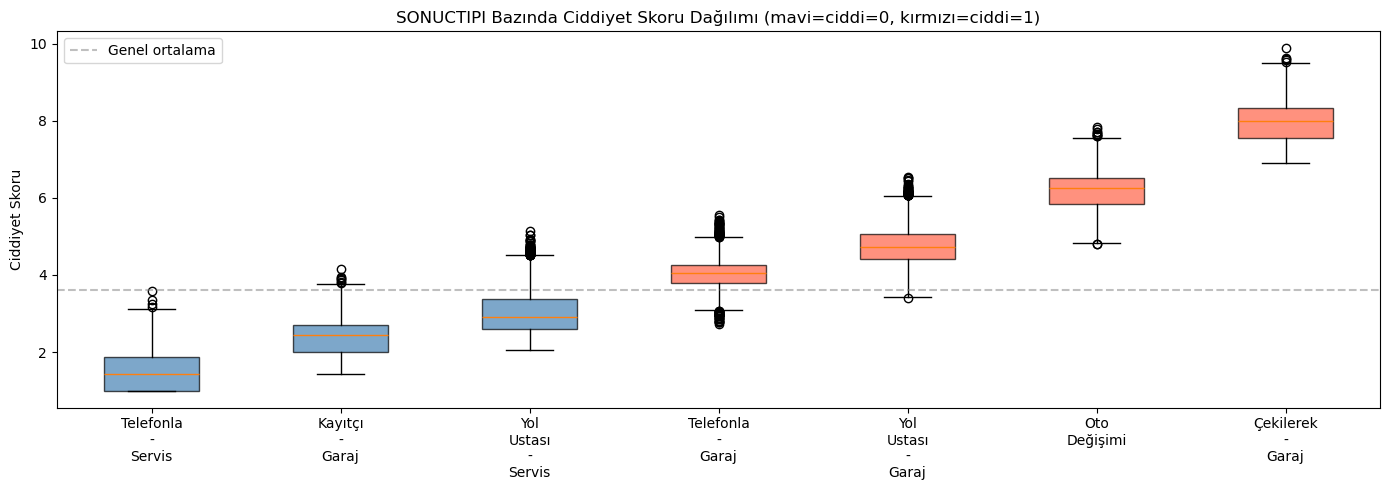

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('panel_data/temiz_veri/ariza_model.csv', low_memory=False)

print('=== SONUCTIPI BAZINDA SKOR İSTATİSTİKLERİ ===')
ozet = df.groupby('SONUCTIPI')['ciddiyet_skoru'].agg(['mean','median','min','max','std']).round(2)
ozet['ciddi_pct'] = (df.groupby('SONUCTIPI')['ciddi_ariza'].mean()*100).round(1)
ozet['n'] = df.groupby('SONUCTIPI')['ciddi_ariza'].count()
print(ozet.sort_values('mean').to_string())

print('\n=== CİDDİ=1 İKİ GRUBU ===')
# Düşük ciddi=1 grubu (skor 2-5)
grup1 = df[(df['ciddi_ariza']==1) & (df['ciddiyet_skoru'] < 5)]
grup2 = df[(df['ciddi_ariza']==1) & (df['ciddiyet_skoru'] >= 5)]
print(f'Grup 1 (skor<5): {len(grup1):,} kayıt')
print(grup1['SONUCTIPI'].value_counts().to_string())
print(f'\nGrup 2 (skor≥5): {len(grup2):,} kayıt')
print(grup2['SONUCTIPI'].value_counts().to_string())

# Admin kodların skorları
print('\n=== ADMİN KODLARIN ORTALAMA SKORU ===')
admin_kodlar = ['Zamanında Müdahale Edilmeme','Yoldan çekici hizmeti',
                'Garajlar arası çekici hizmeti','Sınıflandırılmadı']
for k in admin_kodlar:
    sub = df[df['ARIZAKODU']==k]
    if len(sub) > 0:
        print(f'  {k[:40]}: n={len(sub):,} | ort skor={sub["ciddiyet_skoru"].mean():.2f} | ciddi=%{sub["ciddi_ariza"].mean()*100:.1f}')

# Grafik: her SONUCTIPI için box plot
sonuc_sirali = ['Telefonla - Servis','Kayıtçı - Garaj','Yol Ustası - Servis',
                'Telefonla - Garaj','Yol Ustası - Garaj','Oto Değişimi','Çekilerek - Garaj']
fig, ax = plt.subplots(figsize=(14, 5))
data = [df[df['SONUCTIPI']==s]['ciddiyet_skoru'].values for s in sonuc_sirali]
bp = ax.boxplot(data, labels=[s.replace(' ',  '\n') for s in sonuc_sirali],
                patch_artist=True, notch=False)
renkler = ['steelblue','steelblue','steelblue','tomato','tomato','tomato','tomato']
for patch, renk in zip(bp['boxes'], renkler):
    patch.set_facecolor(renk)
    patch.set_alpha(0.7)
ax.axhline(df['ciddiyet_skoru'].mean(), color='gray', linestyle='--', alpha=0.5, label='Genel ortalama')
ax.set_title('SONUCTIPI Bazında Ciddiyet Skoru Dağılımı (mavi=ciddi=0, kırmızı=ciddi=1)')
ax.set_ylabel('Ciddiyet Skoru')
ax.legend()
plt.tight_layout()
plt.show()


## 35. Son Kontrol — Null + Fallback Mantığı Doğrulaması

In [32]:
import pandas as pd
import numpy as np

df = pd.read_csv('panel_data/temiz_veri/ariza_model.csv', low_memory=False)

# ── TEST 1: NULL KONTROLÜ ──────────────────────────────────
print('=== TEST 1: NULL KONTROLÜ ===')
null_skor = df['ciddiyet_skoru'].isna().sum()
print(f'ciddiyet_skoru null: {null_skor}')
print(f'ciddiyet_skoru min: {df["ciddiyet_skoru"].min():.2f} | max: {df["ciddiyet_skoru"].max():.2f}')
print(f'Toplam kayıt: {len(df):,}')
print(f'Skor dolu kayıt: {df["ciddiyet_skoru"].notna().sum():,}')

if null_skor > 0:
    print(f'\nNull olan kayıtlar:')
    print(df[df['ciddiyet_skoru'].isna()][['KAPINO','SONUCTIPI','ARIZAKODU','ARIZAUSTKODTANIM']].head(10).to_string(index=False))
else:
    print('→ Null yok ✓')

# ── TEST 2: FALLBACK MANTIĞI — get_a_puan fonksiyonu doğrulama ──
print('\n=== TEST 2: FALLBACK MANTIĞI DOĞRULAMASI ===')

# Parametreleri yeniden hesapla (fonksiyonu test için)
admin_arizakodlari = [
    'Zamanında Müdahale Edilmeme', 'Yoldan çekici hizmeti',
    'Yoldan Çekici Hizmeti', 'Garajlar arası çekici hizmeti',
    'Garaj içi Çekici Hizmeti', 'Sınıflandırılmadı'
]
global_puan = round(df['ciddi_ariza'].mean() * 10, 2)
ust_ozet = df.groupby('ARIZAUSTKODTANIM')['ciddi_ariza'].agg(['mean','count'])
ozel_ust = ['Destek','Sınıflandırılmadı']
az_ust = ust_ozet[ust_ozet['count'] < 10].index.tolist()
ust_dict = {k: (global_puan if k in ozel_ust+az_ust else round(v['mean']*10, 2))
            for k, v in ust_ozet.iterrows()}
alt_ozet = df[~df['ARIZAKODU'].isin(admin_arizakodlari)].groupby('ARIZAKODU')['ciddi_ariza'].agg(['mean','count'])
alt_dict = {k: round(v['mean']*10, 2) for k, v in alt_ozet[alt_ozet['count'] >= 30].iterrows()}

def get_a_puan(row):
    if row['ARIZAKODU'] in admin_arizakodlari:
        return ust_dict.get(row['ARIZAUSTKODTANIM'], global_puan)
    if row['ARIZAKODU'] in alt_dict:
        return alt_dict[row['ARIZAKODU']]
    return ust_dict.get(row['ARIZAUSTKODTANIM'], global_puan)

# Garajlar arası çekici — güncellenmiş ARIZAUSTKODTANIM olanlar
garaj_tr = df[df['ARIZAKODU'] == 'Garajlar arası çekici hizmeti'].copy()
garaj_tr['a_puan_hesap'] = garaj_tr.apply(get_a_puan, axis=1)

print('Garajlar arası çekici hizmeti için a_puan dağılımı:')
print(f'  Global puan ({global_puan}) alan: {(garaj_tr["a_puan_hesap"]==global_puan).sum():,}')
print(f'  ARIZAUSTKODTANIM puanı alan: {(garaj_tr["a_puan_hesap"]!=global_puan).sum():,}')
print(f'  a_puan ort: {garaj_tr["a_puan_hesap"].mean():.2f} | min: {garaj_tr["a_puan_hesap"].min():.2f} | max: {garaj_tr["a_puan_hesap"].max():.2f}')

print('\nAyrıntı: ARIZAUSTKODTANIM bazında a_puan:')
ozet = garaj_tr.groupby('ARIZAUSTKODTANIM').agg(
    n=('a_puan_hesap','count'),
    a_puan=('a_puan_hesap','first')
).reset_index().sort_values('n', ascending=False)
print(ozet.to_string(index=False))

print('\n=== BEKLENEN vs GERÇEK: 5 SENARYO EL İLE DOĞRULANİ ===')
senaryolar = [
    ('TURBO HORTUM KELEPÇESİ ARIZALI', 'MOTOR ARIZALARI', 'Yol Ustası - Servis'),
    ('OTO ÇEKMİYOR', 'MOTOR ARIZALARI', 'Çekilerek - Garaj'),
    ('KAPI AYARI', 'KAPI ARIZALARI', 'Telefonla - Servis'),
    ('FRENLER SIKIYOR', 'FREN ŞİKAYETLERİ', 'Yol Ustası - Garaj'),
    ('Zamanında Müdahale Edilmeme', 'Destek', 'Çekilerek - Garaj'),
]
for arizakodu, arizaust, sonuctipi in senaryolar:
    row = pd.Series({'ARIZAKODU': arizakodu, 'ARIZAUSTKODTANIM': arizaust, 'SONUCTIPI': sonuctipi})
    a = get_a_puan(row)
    s = {'Telefonla - Servis':1,'Kayıtçı - Garaj':2,'Yol Ustası - Servis':3,
         'Telefonla - Garaj':4,'Yol Ustası - Garaj':5,'Oto Değişimi':7,'Çekilerek - Garaj':10}.get(sonuctipi,0)
    skor = min(max(s*0.65 + a*0.25 + 2.5*0.10, 1), 10)
    print(f'  [{sonuctipi[:20]:20}] {arizakodu[:35]:35} a_puan={a:.2f} skor≈{skor:.2f}')

print('\n=== TEST 3: SKOR HISTOGRAMı (ciddiyet_skoru değer dağılımı) ===')
bins = [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
hist = pd.cut(df['ciddiyet_skoru'], bins=bins, right=True)
print(hist.value_counts().sort_index().to_string())
print(f'\n10.0 tam değeri alan: {(df["ciddiyet_skoru"]==10.0).sum()}')
print(f'1.0 tam değeri alan: {(df["ciddiyet_skoru"]==1.0).sum()}')


=== TEST 1: NULL KONTROLÜ ===
ciddiyet_skoru null: 0
ciddiyet_skoru min: 1.00 | max: 9.88
Toplam kayıt: 58,559
Skor dolu kayıt: 58,559
→ Null yok ✓

=== TEST 2: FALLBACK MANTIĞI DOĞRULAMASI ===
Garajlar arası çekici hizmeti için a_puan dağılımı:
  Global puan (3.8) alan: 234
  ARIZAUSTKODTANIM puanı alan: 210
  a_puan ort: 4.05 | min: 2.02 | max: 9.51

Ayrıntı: ARIZAUSTKODTANIM bazında a_puan:
                  ARIZAUSTKODTANIM   n  a_puan
                            Destek 234    3.80
        ELEKTRİK SİSTEMİ ARIZALARI  32    2.46
           SOĞUTMA SİSTEMİ ARIZASI  25    2.68
                   MOTOR ARIZALARI  20    5.48
       OTOMATİK ŞANZIMAN ARIZALARI  17    5.55
                    KAPI ARIZALARI  15    2.52
                  FREN ŞİKAYETLERİ  14    6.80
                 KAROSER ARIZALARI  11    2.82
           KLİMA SİSTEMİ ARIZALARI  10    3.06
İLAVE DİREKSİYON SİSTEMİ ARIZALARI   9    4.24
  BASINÇLI HAVA DONANIMI ARIZALARI   7    4.49
             YANGIN İKAZ ARIZALARI   7 